# Pràctica 2
Autors: Ashlie Ventura i Natalia Rodríguez

# Detecció d'opinions
La primera part de la pràctica 2 consisteix en la detecció d'opinions i la seva classificació com a positives o negatives. El primer pas ha estat importar les dades que s'utilitzaran com a corpus.



In [1]:
import nltk
nltk.download('movie_reviews')
from nltk.corpus import movie_reviews as mr


[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Natalia\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


## Algoritmes d'aprenentatge supervisat

### Preparació de les dades

La primera part de la preparació de les dades consisteix a netejar-les. Aquest procés inclou tres passos principals:
Primer, normalitzem el text posant-lo tot en minúscules i eliminant qualsevol caràcter que no sigui una lletra de l'alfabet (a-z), com ara números, signes de puntuació o símbols especials. Això evita que el model tracti "genial!", "genial," i "genial" com tres paraules diferents.
Segon, lematitzem el text, és a dir, reduïm cada paraula a la seva forma base o lema. Per exemple, "running", "runs" i "ran" es converteixen totes en "run". Gràcies a això, el vocabulari és molt més compacte i el model pot aprendre millor les relacions entre paraules.
Tercer, eliminem les stopwords de l'anglès per quedar-nos només amb aquelles paraules que poden aportar significat i ajudar a la classificació de les opinions. Tot i això, s'ha tingut en compte que les opinions negatives sovint contenen expressions com "I don't like..." o "It's not a...", de manera que les negacions com "not", "don't" i "no" s'han conservat al text per tal de facilitar al model l'aprenentatge de patrons per distingir opinions positives i negatives.

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

#no treure les negacions, nomes les paraules amb significat -> dont, not

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text_string(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if (t not in stop_words and len(t) > 1) or (t == "not") or (t == "don't") or (t == "no")
    ]

    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Natalia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Natalia\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


El corpus "movie_review" ja compta amb les etiquetes "pos" i "neg" per a opinions positives i negatives respectivament. Per preparar les dades, hem separat aquestes etiquetes i hem dividit el corpus en train i test, amb un 20% del corpus per al test i un 80% per a l'entrenament dels models.
A més, s'aplica la funció feta anteriorment, que deixa el text net per poder entrenar els models adequadament.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Separar les etiquetes ("pos" i "neg") que fan referència a la categoria
documents = []
labels = []

for categoria in mr.categories():
    for fileid in mr.fileids(categoria):
        raw_text = mr.raw(fileid)                 
        clean_text = clean_text_string(raw_text)  

        if clean_text:                            
            documents.append(clean_text)
            labels.append(categoria)

# Si no fem això a vegades s'afageixen opinions buides i genera errors, 
# per tant, només si hi ha text s'afageix a les dades

# Divisió del corpus train/test

X_train, X_test, y_train, y_test = train_test_split(
    documents, labels, test_size=0.2, random_state=42
)


A continuació, com que les dades són strings, les convertim a números, ja que els models que hem escollit per classificar només funcionen amb valors numèrics. Per fer això, utilitzem CountVectorizer, que converteix el text en vectors numèrics.

Hem d'escollir l'hiperparàmetre max_features, que fa referència a la mida del vocabulari que utilitzarà el model. Per escollir-lo, cal tenir en compte que si és massa petit es perdrà molta informació, i si és massa gran augmentarà considerablement el cost computacional.

Tenim aprop de 40.000 paraules per tant hem escollit aquest possibles valors per l'hiperparàmetre: [100, 5000, 12000, 20000]


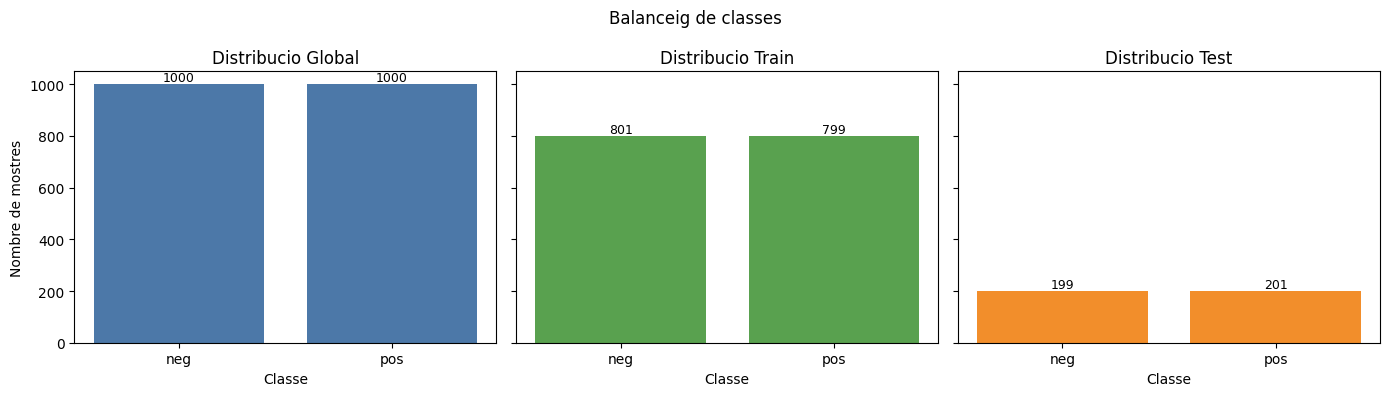

GLOBAL: {'neg': 1000, 'pos': 1000}
TRAIN: {'neg': 801, 'pos': 799}
TEST: {'pos': 201, 'neg': 199}


In [4]:
# Comprovacio de balanc de classes (global, train i test)
from collections import Counter
import matplotlib.pyplot as plt

global_counts = Counter(labels)
train_counts = Counter(y_train)
test_counts = Counter(y_test)

classes = sorted(global_counts.keys())
global_values = [global_counts.get(c, 0) for c in classes]
train_values = [train_counts.get(c, 0) for c in classes]
test_values = [test_counts.get(c, 0) for c in classes]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

axes[0].bar(classes, global_values, color="#4C78A8")
axes[0].set_title("Distribucio Global")
axes[0].set_ylabel("Nombre de mostres")

axes[1].bar(classes, train_values, color="#59A14F")
axes[1].set_title("Distribucio Train")

axes[2].bar(classes, test_values, color="#F28E2B")
axes[2].set_title("Distribucio Test")

for ax, vals in zip(axes, [global_values, train_values, test_values]):
    for i, v in enumerate(vals):
        ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
    ax.set_xlabel("Classe")

plt.suptitle("Balanceig de classes")
plt.tight_layout()
plt.show()

print("GLOBAL:", dict(global_counts))
print("TRAIN:", dict(train_counts))
print("TEST:", dict(test_counts))

Per últim, hem observat gràficament el balanceig de les dues classes "pos" i "neg" de les nostres dades per descobrir si caldria realitzar alguna mètrica determinada o fins i tot generar algun pes en els models per tal d'obtenir models no esbiaixats.
En aquest cas tant les dades globals, com amb les que entrenen i fem el test es troben balancejades.

### SVM (Super Vector Machine)

Per entrenar el primer model escollit s'ha fet un GridSearch on s'avaluen diferents combinacions d'hiperparàmetres, tant del propi SVM, com ara el kernel i el paràmetre C, com del pas de vectorització, concretament el max_features. D'aquesta manera, s'escollirà el millor conjunt d'hiperparàmetres en funció de l'accuracy i altres mètriques i amb aquest conjunt òptim s'entrenarà el model final.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Pipeline: vectorització + classificació
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("svc", SVC())
])

param_grid = {
    "vect__max_features": [100, 5000, 12000, 20000],
    "svc__kernel": ["linear", "rbf", "poly"],
    "svc__C": [0.001, 0.1, 1, 10],
    "svc__gamma": ["scale", "auto"]
}

# Cerca exhaustiva per validació creuada
grid_sv = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_sv.fit(X_train, y_train)

print("Millors paràmetres:", grid_sv.best_params_)
print(f"Millor accuracy CV: {grid_sv.best_score_:.4f}")

best_model_sv = grid_sv.best_estimator_
y_pred_sv = best_model_sv.predict(X_test)

print(f"\nAccuracy test: {accuracy_score(y_test, y_pred_sv):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_sv))


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Millors paràmetres: {'svc__C': 10, 'svc__gamma': 'auto', 'svc__kernel': 'rbf', 'vect__max_features': 12000}
Millor accuracy CV: 0.8344

Accuracy test: 0.8175

Classification report:

              precision    recall  f1-score   support

         neg       0.81      0.83      0.82       199
         pos       0.83      0.80      0.82       201

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400




Després de realitzar l'experimentació mitjançant Cross-Validation de 5 folds, avaluant 96 combinacions d'hiperparàmetres, el millor conjunt trobat per al SVM és el següent: una C de 10, un gamma de auto, un kernel de tipus rbf i un max_features de 12.000.

Amb aquest conjunt d'hiperparàmetres s'obté un accuracy sobre el test de 0.8125. Per confirmar que el model generalitza correctament, també s'analitzen la precisió, el recall i el F1-score, on s'observa que el model no està esbiaixat cap a cap de les dues classes.

### XGBoost

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# XGBoost requereix classes numèriques (0/1)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Pipeline: vectorització + classificació
pipe = Pipeline([
    ("vect", CountVectorizer()),
    ("xgb", XGBClassifier(eval_metric="logloss", verbosity=0))
])

param_grid_xgb = {
    "vect__max_features": [100, 5000, 12000, 20000],
    "xgb__n_estimators": [50, 100, 300],
    "xgb__max_depth": [3, 6, 9],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
}

grid_xgb = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid_xgb,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train_enc)

print("Millors paràmetres:", grid_xgb.best_params_)
print(f"Millor accuracy CV: {grid_xgb.best_score_:.4f}")

best_model_xgb = grid_xgb.best_estimator_
y_pred_enc = best_model_xgb.predict(X_test)
y_pred_xgb = label_encoder.inverse_transform(y_pred_enc)

print(f"\nAccuracy test: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Millors paràmetres: {'vect__max_features': 5000, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 300}
Millor accuracy CV: 0.8162

Accuracy test: 0.8350

Classification report:

              precision    recall  f1-score   support

         neg       0.81      0.87      0.84       199
         pos       0.86      0.80      0.83       201

    accuracy                           0.83       400
   macro avg       0.84      0.84      0.83       400
weighted avg       0.84      0.83      0.83       400



Pel que fa a XGBoost, s'han avaluat 108 combinacions diferents mitjançant Cross-Validation de 5 folds. El millor conjunt d'hiperparàmetres obtingut és el següent: un max_features de 12.000, un learning_rate de 0.05, un max_depth de 3 i un n_estimators de 300.
En aquest cas, l'accuracy obtinguda en el test és superior a la del SVM. Igual que abans, s'analitzen la precisió, el recall i el F1-score per verificar que el model ha après patrons de manera equilibrada i no afavoreix cap de les dues classes.



### Regressió Logística

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Pipeline: vectorització + classificació
pipe_rl = Pipeline([
    ("vect", CountVectorizer()),
    ("logreg", LogisticRegression(max_iter=3000))
])

# Grid de paràmetres per a Regressió Logística
param_grid_rl = [
    {
        "vect__max_features": [100, 5000, 12000, 20000],
        "logreg__penalty": ["l1", "l2"],
        "logreg__C": [0.01, 0.1, 1, 10]
    }
]

grid_rl = GridSearchCV(
    estimator=pipe_rl,
    param_grid=param_grid_rl,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rl.fit(X_train, y_train)

print("Millors paràmetres:", grid_rl.best_params_)
print(f"Millor accuracy CV: {grid_rl.best_score_:.4f}")

best_model_rl = grid_rl.best_estimator_
y_pred_rl = best_model_rl.predict(X_test)

print(f"\nAccuracy test: {accuracy_score(y_test, y_pred_rl):.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred_rl))

Fitting 5 folds for each of 32 candidates, totalling 160 fits


c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
80 fits failed out of a total of 160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\pipeline.py", line 621,

Millors paràmetres: {'logreg__C': 0.01, 'logreg__penalty': 'l2', 'vect__max_features': 5000}
Millor accuracy CV: 0.8450

Accuracy test: 0.8300

Classification report:

              precision    recall  f1-score   support

         neg       0.82      0.85      0.83       199
         pos       0.84      0.81      0.83       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



c:\Users\ashve\IA\q4\PLH\Lab\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Per últim, s'ha emprat una regressió logística on s'han explorat diferents regularitzacions i valors del paràmetre max_features del CountVectorizer. En aquest cas, el conjunt d'hiperparàmetres amb millors mètriques és el següent: una C de 0.01, una regularització de tipus l2 i un max_features de 5.000, obtenint un accuracy en el test de 0.83.

## Protocol de Validació Models Finals

En aquest apartat s'avaluaran els 3 models finals amb els hiperparàmetres obtinguts en la fase d'experimentació. Per fer-ho, s'aplicarà un protocol de validació que inclou tres anàlisis complementàries: la matriu de confusió, per identificar quins tipus d'errors comet cada model; la corba ROC, per mesurar la qualitat global del classificador; i l'anàlisi dels exemples mal classificats, per entendre en quins casos concrets falla cada model.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("COMPARACIO FINAL: SVM vs REGRESSIO LOGISTICA vs XGBOOST")

# 1) Entrenament dels 3 models finals
print("\n1. Entrenant model final de SVM (C=10, kernel=rbf, gamma=auto, max_features=12000)...")
final_svm = Pipeline([
    ("vect", CountVectorizer(max_features=12000)),
    ("svc", SVC(C=10, kernel="rbf", gamma="auto"))
])
final_svm.fit(X_train, y_train)
y_pred_svm = final_svm.predict(X_test)

print("2. Entrenant model final de XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)...")
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
xgb_unigram = Pipeline([
    ("vect", CountVectorizer(max_features=12000, ngram_range=(1, 1))),
    ("xgb", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        eval_metric="logloss",
        verbosity=0
    ))
])
xgb_unigram.fit(X_train, y_train_enc)
y_pred_unigram_enc = xgb_unigram.predict(X_test)
y_pred_unigram = label_encoder.inverse_transform(y_pred_unigram_enc)

print("3. Entrenant model final de Regressio Logistica (max_features=5000, C=0.01, penalty=l2)")
final_rl = Pipeline([
    ("vect", CountVectorizer(max_features=5000)),
    ("logreg", LogisticRegression(C=0.01, penalty="l2", solver="lbfgs", max_iter=3000))
])
final_rl.fit(X_train, y_train)
y_pred_rl = final_rl.predict(X_test)

# Variables comunes i contenidor de resultats
y_test_arr = np.array(y_test)
y_test_bin = (y_test_arr == "pos").astype(int)
results_summary = []

def valida_i_mostra(model_name, model, y_pred):
    print("\n" + "=" * 90)
    print(f"MODEL: {model_name}")
    print("=" * 90)

    # Metriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label="pos", zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label="pos", zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label="pos", zero_division=0)

    print("\nMETRIQUES DE RENDIMENT:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    results_summary.append({
        "Model": model_name.split("(")[0].strip(),
        "Accuracy": f"{accuracy:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
        "F1-Score": f"{f1:.4f}"
    })

    # Matriu de confusio
    print("\nMATRIU DE CONFUSIO:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  {'':15} Prediccio Neg  Prediccio Pos")
    print(f"  Real Neg:       {cm[0,0]:6d}         {cm[0,1]:6d}")
    print(f"  Real Pos:       {cm[1,0]:6d}         {cm[1,1]:6d}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
    disp.plot(cmap="Blues")
    plt.title(f"Matriu de Confusio - {model_name.split('(')[0].strip()}")
    plt.tight_layout()
    plt.show()

    # Corba ROC-AUC
    print("\nCORBA ROC-AUC:")
    try:
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_proba = model.decision_function(X_test)
        else:
            y_proba = model.predict(X_test).astype(float)

        fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
        roc_auc = auc(fpr, tpr)
        print(f"  AUC Score: {roc_auc:.4f}")

        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC={roc_auc:.3f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"Corba ROC - {model_name.split('(')[0].strip()}")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  Error calculant ROC: {e}")

    # Errors
    print("\nANALISI D'ERRORS:")
    errors_mask = y_pred != y_test_arr
    num_errors = np.sum(errors_mask)
    error_rate = num_errors / len(y_test_arr)
    print(f"  Nombre d'errors: {num_errors} / {len(y_test_arr)}")
    print(f"  Taxa d'errors: {error_rate:.4f} ({error_rate * 100:.2f}%)")

COMPARACIO FINAL: SVM vs REGRESSIO LOGISTICA vs XGBOOST

1. Entrenant model final de SVM (C=10, kernel=rbf, gamma=auto, max_features=12000)...
2. Entrenant model final de XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)...
3. Entrenant model final de Regressio Logistica (max_features=5000, C=0.01, penalty=l2)


c:\Natalia\Inteligencia Artificial\Q4\PLH\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



MODEL: SVM (RBF, C=10, max_features=12000)

METRIQUES DE RENDIMENT:
  Accuracy:  0.8175
  Precision: 0.8299
  Recall:    0.8010
  F1-Score:  0.8152

MATRIU DE CONFUSIO:
                  Prediccio Neg  Prediccio Pos
  Real Neg:          166             33
  Real Pos:           40            161


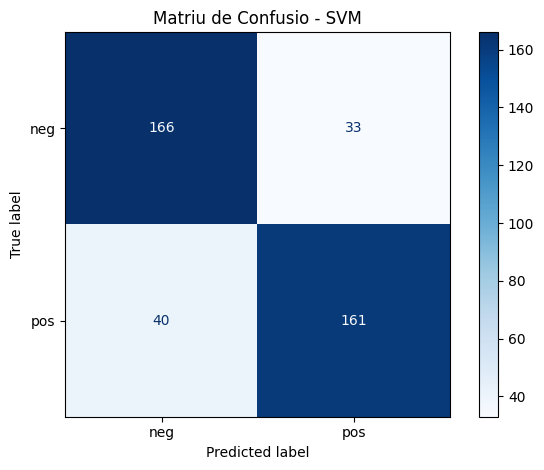


CORBA ROC-AUC:
  AUC Score: 0.8879


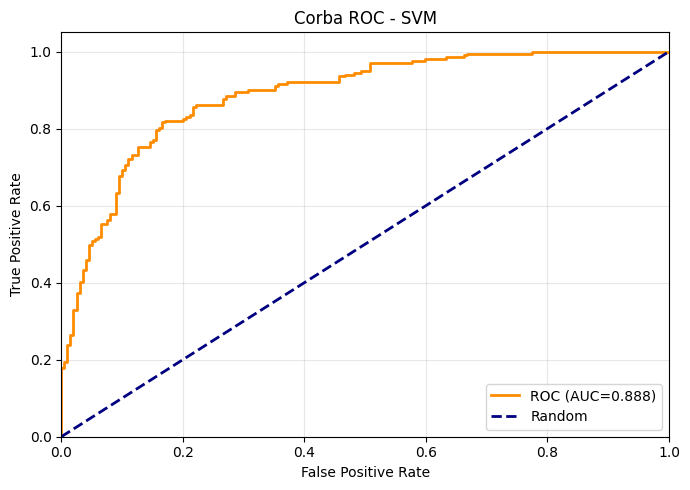


ANALISI D'ERRORS:
  Nombre d'errors: 73 / 400
  Taxa d'errors: 0.1825 (18.25%)


In [7]:
# Validacio SVM
valida_i_mostra(
    "SVM (RBF, C=10, max_features=12000)",
    final_svm,
    y_pred_svm
)

## Anàlisis SVM

Gràcies a la matriu de confusió podem observar que, a més d'obtenir un bon accuracy, el model no prioritza cap de les dues classes, cosa que és senyal d'un bon aprenentatge equilibrat, malgrat hi hagi alguns FN més que FP. Malgrat això, ha comès alguns errors que, analitzant-los, ens permeten deduir quins són els principals problemes del model a l'hora de classificar.

Pel que fa a la corba ROC, s'obté un AUC de 0.8879, la qual cosa indica que es tracta d'un classificador de bona qualitat.
Quant als errors, se n'han identificat quatre causes principals:

La primera és el pes enganyós de certes paraules. El model associa paraules com "successful", "happy" o "never" a una classe concreta, quan en realitat el seu sentiment depèn del context. Per exemple, a l'error 3, la paraula "successful" apareix dues vegades en una ressenya negativa i fa que el model la classifiqui com a positiva. De manera similar, a l'error 34, la paraula "happy" indueix el model a error en una ressenya positiva, i a l'error 6, "never" fa que una ressenya positiva es classifiqui com a negativa.

La segona causa són la ironia i el sarcasme. El model no és capaç d'entendre el context global d'una frase. A l'error 14, la ressenya descriu "battlefield earth" com el pitjor film de l'any, però paraules com "guarantee" fan que el model la classifiqui com a positiva. De manera semblant, a l'error 21, el crític valora positivament "evil dead ii" precisament pels seus defectes, "bad movie", "terrible acting", cosa que el model és incapaç de capturar.

La tercera causa és el vocabulari temàtic enganyós. Certes paraules estan tan associades a un sentiment concret dins del corpus que el model les utilitza com a indicadors independentment del context. Als errors 29 i 49, la paraula "Disney" apareix en ressenyes negatives, però com que en el corpus majoritàriament apareix en ressenyes positives, el model la classifica erròniament com a positiva.

La quarta causa són les ressenyes amb estructura mixta. Algunes ressenyes comencen elogiant aspectes de la pel·lícula i acaben criticant-la, o a l'inrevés. A l'error 5, la ressenya comença amb "steve martin one funniest men alive" però conclou que la pel·lícula és una decepció. El model es queda amb el sentiment predominant de les primeres paraules i no és capaç de capturar el gir negatiu final.

Malgrat això compta amb un Accuracy de 0.8175.



MODEL: Regressio Logistica (C=0.01, penalty=l2, max_features=5000)

METRIQUES DE RENDIMENT:
  Accuracy:  0.8175
  Precision: 0.8232
  Recall:    0.8109
  F1-Score:  0.8170

MATRIU DE CONFUSIO:
                  Prediccio Neg  Prediccio Pos
  Real Neg:          164             35
  Real Pos:           38            163


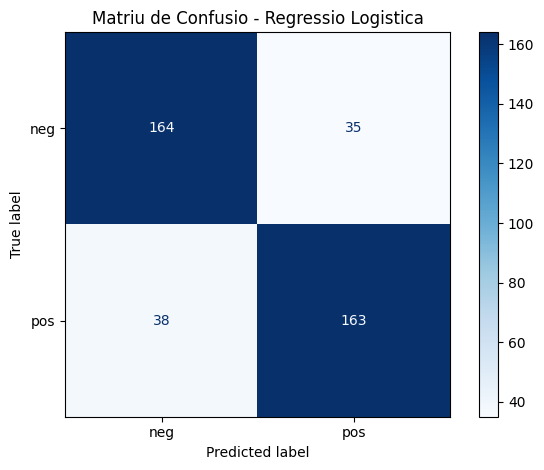


CORBA ROC-AUC:
  AUC Score: 0.8936


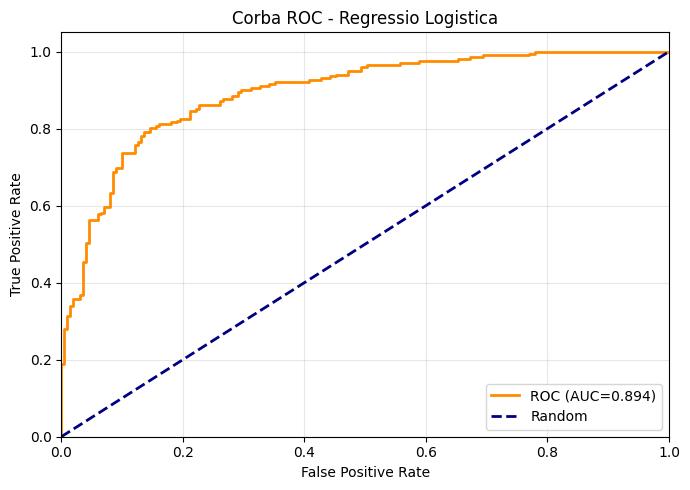


ANALISI D'ERRORS:
  Nombre d'errors: 73 / 400
  Taxa d'errors: 0.1825 (18.25%)


In [8]:
# Validacio Regressio Logistica
valida_i_mostra(
    "Regressio Logistica (C=0.01, penalty=l2, max_features=5000)",
    final_rl,
    y_pred_rl
)

## Anàlisis Regressió Logística

Pel que fa a la Regressió Logística, la matriu de confusió mostra una diferència molt petita entre els falsos positius i els falsos negatius, cosa que indica que el model és encara més equilibrat que el SVM i no tendeix cap a cap classe majoritària. Quant a la corba ROC, s'obté un AUC de 0.8936, lleugerament superior al del SVM, la qual cosa suggereix una millor capacitat d'aprenentatge de patrons. L'accuracy assolida és de 0.8175, amb resultats també en el rang de 0.8-0.9 per a la resta de mètriques com el F1-score i el recall. A continuació s'analitzen alguns dels errors comesos per entendre quines situacions generen una classificació incorrecta.

En el cas de la Regressió Logística, els errors comesos segueixen una línia semblant als del model anterior, encara que amb algunes particularitats pròpies.

Un primer bloc d'errors s'explica per la càrrega semàntica individual de certes paraules. El model aprèn a associar determinades paraules a una classe concreta, però aquest aprenentatge falla quan apareixen en un context diferent. A l'error 65, el terme "successful" apareix en una ressenya negativa sobre Woody Allen i confon el model. De manera similar, a l'error 63, la mateixa paraula torna a aparèixer en una ressenya clarament negativa, on es descriu una pel·lícula com a candidata al pitjor film de l'any.

Un segon bloc d'errors prové de la incapacitat del model per detectar ironia i sarcasme. A l'error 66, la ressenya descriu "Armageddon" com una pel·lícula que "symbolizes everything wrong modern filmmaking", però altres paraules del text fan decantar el model cap a la classe negativa quan en realitat és positiva. L'error 52 és també representatiu: el crític descriu un blockbuster amb "bad script" i malgrat això la ressenya és positiva, ja que valora favorablement altres aspectes de la pel·lícula.

Un tercer bloc respon al biaix introduït per noms propis i marques. Als errors 53 i 58, la presència de termes associats a gèneres o estudis concrets porta el model a classificar incorrectament. A l'error 72, el nom "Terrence Malick" actua com a indicador positiu espuri en una ressenya negativa, atès que aquest director apareix habitualment lligat a valoracions positives dins el corpus.

Finalment, un quart bloc d'errors correspon a ressenyes amb un arc narratiu contradictori. A l'error 57, la ressenya comença descrivint una experiència prèvia positiva abans de girar cap a una valoració negativa de la pel·lícula en qüestió. A l'error 70, el crític reconeix aspectes positius al principi del text abans de concloure amb una valoració negativa, cosa que fa que el model es quedi amb el sentiment dominant de les primeres paraules i no processi el canvi de to posterior.

Aquests patrons coincideixen en gran mesura amb els observats al SVM.
  


MODEL: XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)

METRIQUES DE RENDIMENT:
  Accuracy:  0.8375
  Precision: 0.8542
  Recall:    0.8159
  F1-Score:  0.8346

MATRIU DE CONFUSIO:
                  Prediccio Neg  Prediccio Pos
  Real Neg:          171             28
  Real Pos:           37            164


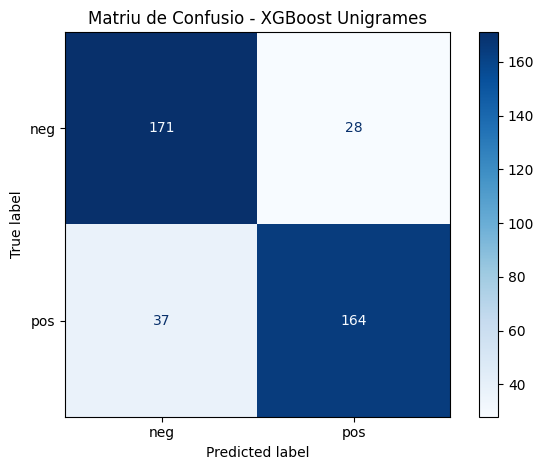


CORBA ROC-AUC:
  AUC Score: 0.9037


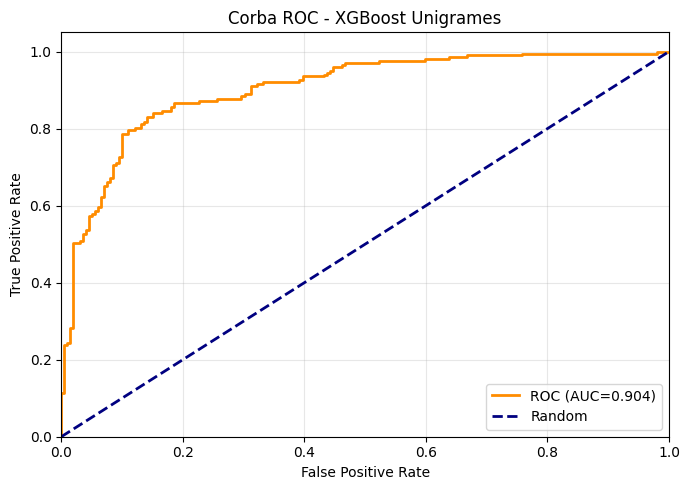


ANALISI D'ERRORS:
  Nombre d'errors: 65 / 400
  Taxa d'errors: 0.1625 (16.25%)


In [9]:
# Validacio XGBoost
valida_i_mostra(
    "XGBoost Unigrames (max_features=12000, n_est=300, depth=3, lr=0.05)",
    xgb_unigram,
    y_pred_unigram
)

## Anàlisis XGBoost


El XGBoost és el model que ofereix els millors resultats globals. La matriu de confusió reflecteix el nombre més baix de classificacions incorrectes dels tres models, i la corba ROC assoleix el valor d'AUC més alt (0.9037). Les mètriques obtingudes sobre el conjunt de test són les següents: un accuracy de 0.8375, una precisió de 0.8542, un recall de 0.8159 i un F1-score de 0.8346. Cal remarcar que el recall és lleugerament inferior a la precisió, tot i que la diferència és poc rellevant i no compromet la qualitat del model.

Malgrat el bon rendiment general, el model comet errors que es poden agrupar en diverses categories.

La primera categoria agrupa els errors causats pel pes de determinades paraules fora de context. El model ha après que certes expressions estan lligades a un sentiment concret, però aquest aprenentatge es trenca quan les mateixes paraules apareixen en un context diferent. A l'error 4, la frase "steve martin one funniest men alive" provoca que el model prevegi un sentiment positiu quan la ressenya és en realitat una crítica negativa a la pel·lícula. A l'error 54, el qualificatiu "successful" aplicat a Woody Allen orienta erròniament el model cap a la classe positiva, malgrat que la ressenya qüestiona la seva trajectòria recent.

La segona categoria recull els errors vinculats a la detecció d'ironia i sarcasme. A l'error 15, expressions com "bad movie", "terrible acting" i "pointless violence" haurien d'indicar un sentiment clarament negatiu, però la ressenya és positiva perquè l'autor considera "Evil Dead II" una obra de culte que val la pena precisament pels seus excessos. A l'error 55, la ressenya critica "Armageddon" com a símbol dels mals del cinema contemporani, però el model no és capaç de llegir el to irònic i la classifica incorrectament.

La tercera categoria engloba els errors provocats pel valor dels noms propis. Tant als errors 31 i 37, la paraula "Disney" apareix en ressenyes negatives, però com que al corpus aquesta marca sol anar acompanyada de valoracions positives, el model la interpreta com un senyal favorable. A l'error 61, el nom "Terrence Malick" genera el mateix efecte: el model associa automàticament aquest director a crítiques positives i falla quan la ressenya és negativa. O el biaix per referències a la cultura popular. A l'error 63, mencions a les Spice Girls i a productes d'entreteniment massius confonen el model. A l'error 2, referències a Mark Wahlberg i a "Boogie Nights", figures amb a un cert prestigi, fan inclinar la predicció cap al sentiment positiu en una ressenya que en realitat és negativa.

La quarta categoria recull els errors deguts a ressenyes contradictories. A l'error 22, el crític comença reconeixent el potencial de la pel·lícula i només al final revela que el resultat és decebedor. A l'error 46, la ressenya s'inicia recordant una experiència cinematogràfica prèvia agradable, però acaba criticant durament la pel·lícula analitzada. En ambdós casos, el model es queda ancorat en el to positiu de l'inici i no detecta el gir negatiu posterior.


En definitiva, tot i que el XGBoost supera els altres dos models en totes les mètriques, els tipus d'errors que comet són essencialment els mateixos. Això confirma que el sostre de rendiment d'aquests models no ve determinat per l'algorisme escollit, sinó per la manera com es representa el text: el CountVectorizer tracta cada paraula com una unitat independent, sense tenir en compte l'ordre, el context ni les relacions semàntiques entre paraules.

## Conclusions 

Després d'analitzar els tres models i comprovar que els seus errors de classificació responen a patrons similars, s'ha decidit escollir el XGBoost com a model final, ja que és el que obté els millors resultats en totes les mètriques avaluades.

In [10]:
# Taula resum comparativa
print("\n" + "=" * 90)
print("TAULA RESUM COMPARATIVA")
print("=" * 90)

df_results = pd.DataFrame(results_summary)
print("\n" + df_results.to_string(index=False))


TAULA RESUM COMPARATIVA

              Model Accuracy Precision Recall F1-Score
                SVM   0.8175    0.8299 0.8010   0.8152
Regressio Logistica   0.8175    0.8232 0.8109   0.8170
  XGBoost Unigrames   0.8375    0.8542 0.8159   0.8346


## MODEL FINAL

Un cop escollit el model final, i havent identificat algunes de les causes dels errors, s'analitzarà si l'ús de bigrames en lloc d'unigrames pot millorar la capacitat predictiva del model, ja que permeten capturar relacions més complexes entre paraules, com ara "don't like". D'aquesta manera es podrà determinar si aquest canvi és suficient per millorar el rendiment o si calen modificacions més profundes.

COMPARACIÓ: XGBoost Unigrames vs XGBoost Bigrames

MODEL: XGBoost Unigrames

MÈTRIQUES DE RENDIMENT:
  Accuracy:  0.8375
  Precision: 0.8542
  Recall:    0.8159
  F1-Score:  0.8346

MATRIU DE CONFUSIÓ:
                  Predicció Neg  Predicció Pos
  Real Neg:          171             28
  Real Pos:           37            164


<Figure size 700x500 with 0 Axes>

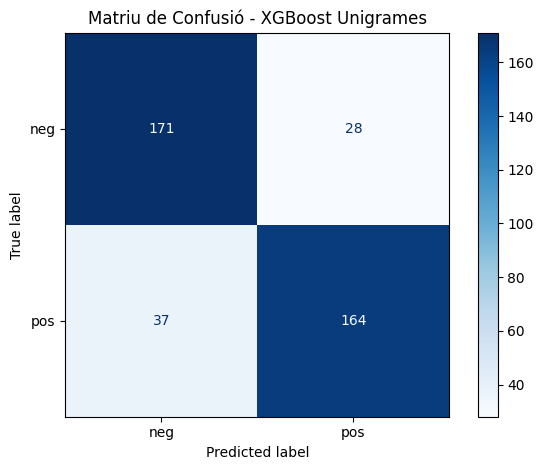


ANÀLISI D'ERRORS:
  Nombre d'errors: 65 / 400
  Taxa d'errors: 0.1625 (16.25%)

  EXEMPLES MAL CLASSIFICATS:

  Error 0:
    Real: pos → Predicció: neg
    Text: 'company men made splash sundance film festival year plagued brother mcmullen style earnestly shallow...'

  Error 1:
    Real: neg → Predicció: pos
    Text: 'year captain leo davidson mark wahlberg boogie night training chimp pericles pilot pod usaf oberon s...'

  Error 2:
    Real: neg → Predicció: pos
    Text: 'following review encompasses two version dune dune theatrical version runtime minute capsule review ...'

  Error 3:
    Real: neg → Predicció: pos
    Text: 'steve martin one funniest men alive take true statement disappointment film equal mine martin hilari...'

  Error 4:
    Real: pos → Predicció: neg
    Text: 'heard many critic describe return old fashioned hollywood romance kept asking going movie exactly ol...'

  Error 5:
    Real: pos → Predicció: neg
    Text: 'inseparable team sgt martin riggs mel gib

<Figure size 700x500 with 0 Axes>

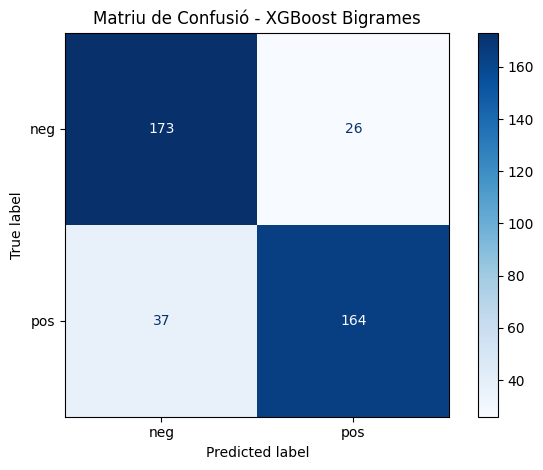


ANÀLISI D'ERRORS:
  Nombre d'errors: 63 / 400
  Taxa d'errors: 0.1575 (15.75%)

  EXEMPLES MAL CLASSIFICATS:

  Error 0:
    Real: neg → Predicció: pos
    Text: 'year captain leo davidson mark wahlberg boogie night training chimp pericles pilot pod usaf oberon s...'

  Error 1:
    Real: neg → Predicció: pos
    Text: 'following review encompasses two version dune dune theatrical version runtime minute capsule review ...'

  Error 2:
    Real: pos → Predicció: neg
    Text: 'vampire lore legend always popular fantasy element substantiated not sheer number movie subject also...'

  Error 3:
    Real: neg → Predicció: pos
    Text: 'steve martin one funniest men alive take true statement disappointment film equal mine martin hilari...'

  Error 4:
    Real: pos → Predicció: neg
    Text: 'heard many critic describe return old fashioned hollywood romance kept asking going movie exactly ol...'

  Error 5:
    Real: pos → Predicció: neg
    Text: 'inseparable team sgt martin riggs mel gib

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

print("="*90)
print("COMPARACIÓ: XGBoost Unigrames vs XGBoost Bigrames")

# 1. ENTRENAR MODEL FINAL DE XGBOOST AMB BIGRAMES

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

xgb_bigram = Pipeline([
    ("vect", CountVectorizer(max_features=12000, ngram_range=(1, 2))),
    ("xgb", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, 
                          eval_metric="logloss", verbosity=0))
])

xgb_bigram.fit(X_train, y_train_enc)
y_pred_bigram_enc = xgb_bigram.predict(X_test)
y_pred_bigram = label_encoder.inverse_transform(y_pred_bigram_enc)

# 2. COMPARACIÓ DELS DOS MODELS
y_test_arr = np.array(y_test)

models_xgb = {
    "XGBoost Unigrames": {
        "model": xgb_unigram,
        "predictions": y_pred_unigram
    },
    "XGBoost Bigrames": {
        "model": xgb_bigram,
        "predictions": y_pred_bigram
    }
}

results = []

for model_name, model_info in models_xgb.items():
    model = model_info["model"]
    y_pred = model_info["predictions"]
    
    print("\n" + "="*90)
    print(f"MODEL: {model_name}")
    print("="*90)
    
    # MÈTRIQUES
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label="pos", zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label="pos", zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label="pos", zero_division=0)
    
    print(f"\nMÈTRIQUES DE RENDIMENT:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    results.append({
        "Model": model_name,
        "Accuracy": f"{accuracy:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
        "F1-Score": f"{f1:.4f}"
    })
    
    # MATRIU DE CONFUSIÓ
    print(f"\nMATRIU DE CONFUSIÓ:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  {'':15} Predicció Neg  Predicció Pos")
    print(f"  Real Neg:       {cm[0,0]:6d}         {cm[0,1]:6d}")
    print(f"  Real Pos:       {cm[1,0]:6d}         {cm[1,1]:6d}")
    
    # GRÀFIC MATRIU DE CONFUSIÓ
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
    plt.figure(figsize=(7, 5))
    disp.plot(cmap='Blues')
    plt.title(f"Matriu de Confusió - {model_name}")
    plt.tight_layout()
    plt.show()
    
    # ERRORS I EXEMPLES MAL CLASSIFICATS
    print(f"\nANÀLISI D'ERRORS:")
    errors_mask = y_pred != y_test_arr
    num_errors = np.sum(errors_mask)
    error_rate = num_errors / len(y_test_arr)
    
    print(f"  Nombre d'errors: {num_errors} / {len(y_test_arr)}")
    print(f"  Taxa d'errors: {error_rate:.4f} ({error_rate*100:.2f}%)")
    
    if num_errors > 0:
        print(f"\n  EXEMPLES MAL CLASSIFICATS:")
        error_indices = np.where(errors_mask)[0]
        
        for i, idx in enumerate(error_indices):
            actual = y_test_arr[idx]
            predicted = y_pred[idx]
            text_preview = X_test[idx][:100] + "..." if len(X_test[idx]) > 100 else X_test[idx]
            
            print(f"\n  Error {i}:")
            print(f"    Real: {actual} → Predicció: {predicted}")
            print(f"    Text: '{text_preview}'")

# 3. TAULA RESUM COMPARATIVA
print("\n" + "="*90)
print("TAULA RESUM COMPARATIVA")
print("="*90)

df_xgb = pd.DataFrame(results)
print("\n" + df_xgb.to_string(index=False))

print("\n" + "="*90)
print("CONCLUSIÓ")
print("="*90)

f1_unigram = float(results[0]["F1-Score"])
f1_bigram = float(results[1]["F1-Score"])



## Conclusió Model Final

Comparant els dos models, el que utilitza bigrames obté millors resultats tant en la matriu de confusió com en l'accuracy i, per tant, en la taxa d'errors. Analitzant els errors de tots dos, es poden extreure les conclusions següents sobre l'aportació dels bigrames respecte als unigrames.

El model amb unigrames comet 65 errors, mentre que el model amb bigrames en comet 63. La reducció és molt petita, cosa que indica que els bigrames aporten una millora marginal però no substancial.

Pel que fa als errors que els bigrames han aconseguit resoldre, s'observa que alguns casos que els unigrames classificaven incorrectament desapareixen amb l'ús de parelles de paraules. Per exemple, l'error 14 dels unigrames "evil dead ii bad movie full terrible acting pointless violence"  es classifica correctament amb bigrames, probablement perquè combinacions com "bad movie" o "terrible acting" aporten més context que les paraules aïllades. De manera similar, l'error 43 "bowfinger good movie making bad one" també es resol, ja que parelles com "good movie" i "bad one" ajuden a calibrar millor el sentiment global.

Malgrat això, la gran majoria d'errors es repeteixen en els dos models. Casos com "steve martin one funniest men alive" (error 3 en tots dos), "Woody Allen successful" (errors 53 i 51), "Terrence Malick" (errors 60 i 59) o les Spice Girls (errors 62 i 61) apareixen en ambdues llistes sense variació. Això posa de manifest que els bigrames no resolen els problemes estructurals del model: el biaix introduït per noms propis, la ironia i les ressenyes amb un arc narratiu contradictori continuen sent fonts d'error independentment del tipus de n-grama utilitzat.

A més, els bigrames introdueixen alguns errors nous que els unigrames no cometien, com ara l'error 2 "vampire lore legend always popular fantasy" , l'error 24 "rushmore"  o l'error 44 "razor blade smile". Això suggereix que en determinats casos els bigrames sobreajusten el model a combinacions de paraules molt concretes que no generalitzen bé a exemples nous.

En conclusió, tot i que els bigrames aporten una millora lleugera, no resolen les limitacions fonamentals del model. Per obtenir un increment significatiu del rendiment caldria un enfocament diferent, basat en representacions semàntiques més riques i robustes que tinguin en compte el context global de cada ressenya.

# Pràctica 2.b: Detecció d'Opinions No Supervisada

A diferència de l'aproximació supervisada de la pràctica anterior, en aquesta part s'ha implementat un sistema de detecció d'opinions que no requereix exemples etiquetats per aprendre. L'objectiu és assignar una puntuació de sentiment a cada ressenya a partir del significat lèxic de les seves paraules, utilitzant dos recursos lingüístics externs: WordNet com a base de coneixement lèxic i SentiWordNet com a font de valors de sentiment associats a cada synset.

La idea central és la següent: donada una paraula en context, s'intenta identificar quin synset de WordNet la representa millor i, a partir d'aquest synset, s'obté una puntuació de positivitat i negativitat de SentiWordNet. La diferència entre ambdues puntuacions dona un valor escalar que pot ser positiu, negatiu o neutre. Agregant aquests valors per a totes les paraules rellevants d'un text, s'obté una puntuació global que permet classificar la ressenya com a positiva o negativa.

Un aspecte fonamental del disseny és la tria de les categories gramaticals que s'inclouen en l'anàlisi. No totes les paraules d'un text aporten informació de sentiment amb la mateixa fiabilitat: els adjectius, per exemple, solen ser els portadors més directes d'opinió (*"brilliant"*, *"awful"*), mentre que els noms i els verbs poden introduir soroll si no es gestionen amb cura. Per explorar l'impacte d'aquesta decisió, s'han dissenyat tres configuracions: una que utilitza només adjectius (*Adj*), una que incorpora noms, adjectius i adverbis (*Noms + Adj + Adv*) i una que afegeix també verbs (*Noms + Adj + Verb + Adv*).

A més, per a cada configuració s'han provat tres estratègies de desambiguació de sentit (*Word Sense Disambiguation*, WSD), que determinen com s'escull el synset d'una paraula quan n'hi ha diversos de possibles. *Ignore* aplica l'algoritme de Lesk per escollir el synset més adequat al context i descarta la paraula si no en troba cap. *First* fa el mateix però, si Lesk falla, agafa el primer synset disponible a WordNet. *Average* calcula la puntuació mitjana de tots els synsets possibles de la paraula sense aplicar cap desambiguació.

La combinació d'aquestes dues dimensions dona lloc a nou configuracions experimentals. Atès que el sistema és completament no supervisat (no hi ha cap paràmetre que s'aprengui a partir de les dades) el conjunt de train no intervé en cap fase del càlcul de les puntuacions. Per aquesta raó, totes les nou configuracions s'avaluen directament sobre el conjunt de test que s'ha fet servir a la pràctica 2.a, sense necessitat de reservar dades per a la validació. Això garanteix la comparabilitat dels resultats amb els models supervisats i maximitza el nombre de mostres disponibles per a l'avaluació. El conjunt de train únicament s'utilitza en l'etapa d'ajust del llindar de decisió, descrita més endavant, on sí que és necessari disposar d'un conjunt de referència separat del test.

## Preprocessament del text

El preprocessament és un pas crític en qualsevol sistema de PLN, i en el cas no supervisat ho és especialment: com que no hi ha cap model entrenat que pugui compensar un preprocessament deficient, la qualitat del text que arriba a l'algoritme de sentiment condiciona directament el resultat final.

La funció `clean_text_string` s'encarrega de transformar cada ressenya en brut en una cadena de tokens anotats amb la seva categoria gramatical, amb el format `paraula/POS`. El procés segueix els passos següents. Primer, el text es passa a minúscules i es tokenitza amb el tokenitzador de l'NLTK, que respecta la puntuació i les contraccions (per exemple, *"didn't"* es separa en *"did"* i *"n't"*). La contracció *"n't"* es normalitza explícitament a *"not"*, ja que és semànticament equivalent i cal que sigui reconeguda com a negació en fases posteriors. A continuació, s'aplica l'etiquetador morfosintàctic (*POS tagger*) de l'NLTK, que assigna etiquetes Penn Treebank a cada token.

Un cop etiquetats, els tokens es filtren: s'eliminen les paraules buides (*stop words*) de l'anglès (excepte les negacions, que es preserven perquè poden ser rellevants en models posteriors) i els tokens d'un sol caràcter. Per a cada token que supera el filtre, es netegen els caràcters no alfabètics i s'aplica la lematització amb `WordNetLemmatizer`, passant-li la categoria gramatical correcta perquè el lema resultant sigui el més acurat possible. Finalment, cada token s'emmagatzema amb el format `lema/CATEGORIA`, on la categoria pot ser `ADJ`, `VERB`, `NOUN`, `ADV` o `OTHER`.

In [12]:

import re
import numpy as np
import nltk

from nltk.corpus import stopwords, wordnet as wn, sentiwordnet as swn
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.wsd import lesk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc, classification_report
)


In [13]:
for recurs in ["punkt", "stopwords", "wordnet", "averaged_perceptron_tagger",
               "sentiwordnet", "punkt_tab", "movie_reviews"]:
    nltk.download(recurs, quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
NEGACIONS = {"not", "no", "never", "neither", "nor"}

In [14]:
def penn_to_wn(tag: str):
    """Converteix etiquetes Penn Treebank a etiquetes POS de WordNet."""
    if tag.startswith("J"): return wn.ADJ
    if tag.startswith("V"): return wn.VERB
    if tag.startswith("N"): return wn.NOUN
    if tag.startswith("R"): return wn.ADV
    return None

WN_TAG_MAP = {
    wn.ADJ:  "ADJ",
    wn.VERB: "VERB",
    wn.NOUN: "NOUN",
    wn.ADV:  "ADV"
}

LABEL_TO_WN = {v: k for k, v in WN_TAG_MAP.items()}

In [15]:
def clean_text_string(text: str) -> str:
    """
    Neteja el text, lematitza amb POS correcte i marca negacions.
    Format de sortida: 'word/POS'
    """
    text = text.lower()
    
    # 1. TOKENIZAR PRIMERO (con puntuación intacta para contexto)
    tokens = word_tokenize(text)
    tokens = ["not" if t == "n't" else t for t in tokens]
    
    # 2. POS tagging (ahora funciona correctamente)
    tagged_tokens = pos_tag(tokens)
    
    cleaned_tokens = []
    for word, pos in tagged_tokens:
        # Mantener negaciones aunque sean stopwords
        if (word in stop_words and word not in NEGACIONS) or len(word) <= 1:
            continue
        
        # Limpiar caracteres especiales SOLO en palabras
        word_clean = re.sub(r"[^a-z']", "", word)
        if not word_clean:
            continue
        
        wn_pos = penn_to_wn(pos)
        lemma = lemmatizer.lemmatize(word_clean, pos=wn_pos if wn_pos else wn.NOUN)

        pos_label = WN_TAG_MAP.get(wn_pos, "OTHER")
        cleaned_tokens.append(f"{lemma}/{pos_label}")

    return " ".join(cleaned_tokens)

In [16]:
from nltk.corpus import movie_reviews as mr

documents_ns = []
labels_all      = []

for categoria in mr.categories():
    for fileid in mr.fileids(categoria):
        raw_text   = mr.raw(fileid)
        clean  = clean_text_string(raw_text)
        documents_ns.append(clean)
        labels_all.append(categoria)

# Un sol split — mateix random_state garanteix comparació justa entre models

X_train_ns, X_test_ns, \
y_train_ns, y_test_ns = train_test_split(
    documents_ns, labels_all,
    test_size=0.2, random_state=42
)


print(f"Train: {len(X_train_ns)} mostres | Test: {len(X_test_ns)} mostres")

Train: 1600 mostres | Test: 400 mostres


In [17]:
# Buscar si hi ha 'not' en els texts preprocessats
import re

count_not = sum(1 for text in X_train_ns if bool(re.search(r'\bnot\b|\bNOT\b', text)))
print(f"Textos con 'not': {count_not}/{len(X_train_ns)}")


for i, text in enumerate(X_train_ns[:3]):
    if 'not' in text.lower():
        print(f"Ejemplo {i}: {text[:100]}...")
        break

Textos con 'not': 1544/1600
Ejemplo 0: watch/VERB loser/ADJ occur/VERB amy/VERB heckerling/VERB 's/OTHER true/ADJ genius/NOUN filmmaker/NOU...



### Càlcul de la puntuació de sentiment

La funció principal del sistema és sentiment_score_unsupervised_wsd, que rep el text preprocessat i els paràmetres de configuració (categories POS i estratègia) i retorna la puntuació normalitzada, el nombre de synsets trobats i el nombre de paraules descartades.

Per a cada token del text, es comprova si pertany a una de les categories gramaticals de la configuració activa. Si no és el cas, la paraula es comptabilitza com a no trobada i es passa al token següent. Si sí que pertany a una categoria rellevant, s'actua en funció de l'estratègia escollida.

En les estratègies ignore i first, s'utilitza l'algoritme de Lesk per desambiguar el sentit de la paraula en el seu context. Lesk compara la definició de cada synset candidat amb les paraules del context i escull aquell amb major solapament. Si Lesk no retorna cap synset i l'estratègia és first, s'agafa el primer synset de WordNet, que per convenció sol ser el sentit més freqüent. En l'estratègia average, no es fa cap desambiguació: es recullen tots els synsets de la paraula i se'n calcula la mitjana de les puntuacions de sentiment.

Per a cada synset seleccionat, la funció auxiliar _score_synset consulta SentiWordNet i calcula la puntuació neta com la diferència entre la puntuació positiva i la negativa (pos_score - neg_score). Aquesta diferència pot ser positiva, negativa o zero (en el cas de synsets neutres). Al final del processament, la puntuació total s'normalitza dividint-la pel nombre de synsets vàlids trobats, de manera que la mètrica sigui comparable entre textos de longituds molt diferents. Si no s'ha trobat cap synset, la puntuació és zero.

La classificació final és binària: si la puntuació normalitzada és positiva, la ressenya es prediu com a positiva; si és negativa o zero, com a negativa.



In [18]:
def _score_synset(synset) -> float | None:
    """Retorna la puntuació de sentiment d'un synset o None si no existeix."""
    try:
        swn_synset = swn.senti_synset(synset.name())
        return swn_synset.pos_score() - swn_synset.neg_score()
    except Exception:
        return None

def sentiment_score_unsupervised_wsd(
    clean_text: str,
    pos_categories: list = ["ADJ"],
    strategy: str = "ignore"
) -> tuple:
    tokens_with_pos = clean_text.split()

    context_tokens = [
        t.rsplit("/", 1)[0]
        for t in tokens_with_pos if "/" in t
    ]

    total_score = 0.0
    synsets_found = 0
    synsets_not_found = 0

    for token in tokens_with_pos:
        if "/" not in token:
            continue

        word, pos_label = token.rsplit("/", 1)

        # Tokens fora de les categories simplement s'ignoren, no es compten
        if pos_label == "OTHER" or pos_label not in pos_categories:
            continue

        wn_tag = LABEL_TO_WN.get(pos_label)
        if wn_tag is None:
            continue

        score = None

        if strategy in ("ignore", "first"):
            synset = lesk(context_tokens, word, pos=wn_tag)
            if synset is None and strategy == "first":
                synsets_list = wn.synsets(word, pos=wn_tag)
                synset = synsets_list[0] if synsets_list else None
            if synset:
                score = _score_synset(synset)

        elif strategy == "average":
            synsets_list = wn.synsets(word, pos=wn_tag)
            scores_list = [s for syn in synsets_list
                           if (s := _score_synset(syn)) is not None]
            if scores_list:
                score = float(np.mean(scores_list))

        if score is not None:
            total_score += score
            synsets_found += 1
        else:
            synsets_not_found += 1

    normalized_score = total_score / synsets_found if synsets_found > 0 else 0.0
    return normalized_score, synsets_found, synsets_not_found

### Categories gramaticals avaluades
S'han dissenyat tres configuracions de categories POS per analitzar quines aporten més informació de sentiment:

In [19]:
pos_configs = {
    "Adj": ['ADJ'],
    "Noms + Adj + Adv": ['NOUN', 'ADJ', 'ADV'],
    "Noms + Adj + Verb + Adv": ['NOUN', 'ADJ', 'VERB', 'ADV']
}

strategies = ["ignore", "first", "average"]

In [60]:
unsupervised_results = {}
y_test_arr_ns = np.array(y_test_ns)

for config_name, pos_list in pos_configs.items():
    unsupervised_results[config_name] = {}

    for strategy in strategies:
        print(f"\nConfiguració: {config_name} | Estratègia: {strategy}")

        scores, found_list, not_found_list = [], [], []

        for text in X_test_ns:
            score, found, not_found = sentiment_score_unsupervised_wsd(
                text,
                pos_categories=pos_list,
                strategy=strategy
            )
            scores.append(score)
            found_list.append(found)
            not_found_list.append(not_found)

        scores_arr = np.array(scores)

        # Comprovació de debugging: si tots els scores són 0 avisem
        non_zero = np.sum(scores_arr != 0)
        print(f"  [DEBUG] Scores no zero: {non_zero}/{len(scores_arr)}")

        # Classificació binària: positiu si score > 0
        y_pred = np.where(scores_arr > 0, "pos", "neg")

        # Mètriques d'avaluació
        accuracy  = accuracy_score(y_test_ns, y_pred)
        precision = precision_score(y_test_ns, y_pred, pos_label="pos", zero_division=0)
        recall    = recall_score(y_test_ns, y_pred, pos_label="pos", zero_division=0)
        f1        = f1_score(y_test_ns, y_pred, pos_label="pos", zero_division=0)
        cm        = confusion_matrix(y_test_ns, y_pred)

        # Corba ROC
        y_test_bin  = (y_test_arr_ns == "pos").astype(int)
        scores_norm = (scores_arr - scores_arr.min()) / (scores_arr.max() - scores_arr.min() + 1e-10)
        fpr, tpr, _ = roc_curve(y_test_bin, scores_norm)
        roc_auc     = auc(fpr, tpr)

        errors_mask   = y_pred != y_test_arr_ns
        error_indices = np.where(errors_mask)[0]

        unsupervised_results[config_name][strategy] = {
            "pos_list":      pos_list,
            "scores":        scores_arr,
            "y_pred":        y_pred,
            "accuracy":      accuracy,
            "precision":     precision,
            "recall":        recall,
            "f1":            f1,
            "cm":            cm,
            "synsets_stats": {
                "found":     found_list,
                "not_found": not_found_list,
                "processed": [f + nf for f, nf in zip(found_list, not_found_list)]
            },
            "fpr":           fpr,
            "tpr":           tpr,
            "roc_auc":       roc_auc,
            "errors_mask":   errors_mask,
            "error_indices": error_indices,
            "num_errors":    int(np.sum(errors_mask))
        }

        print(f"  - Accuracy: {accuracy:.3f} | F1: {f1:.3f} | AUC: {roc_auc:.3f}")


Configuració: ADJ | Estratègia: ignore
  [DEBUG] Scores no zero: 393/400
  - Accuracy: 0.642 | F1: 0.688 | AUC: 0.689

Configuració: ADJ | Estratègia: first
  [DEBUG] Scores no zero: 394/400
  - Accuracy: 0.667 | F1: 0.697 | AUC: 0.732

Configuració: ADJ | Estratègia: average
  [DEBUG] Scores no zero: 400/400
  - Accuracy: 0.690 | F1: 0.728 | AUC: 0.750

Configuració: NOUN+ADJ+ADV | Estratègia: ignore
  [DEBUG] Scores no zero: 397/400
  - Accuracy: 0.650 | F1: 0.615 | AUC: 0.725

Configuració: NOUN+ADJ+ADV | Estratègia: first
  [DEBUG] Scores no zero: 394/400
  - Accuracy: 0.680 | F1: 0.646 | AUC: 0.752

Configuració: NOUN+ADJ+ADV | Estratègia: average
  [DEBUG] Scores no zero: 400/400
  - Accuracy: 0.677 | F1: 0.637 | AUC: 0.761

Configuració: ADJ+ADV+VERB+NOUN | Estratègia: ignore
  [DEBUG] Scores no zero: 396/400
  - Accuracy: 0.670 | F1: 0.663 | AUC: 0.723

Configuració: ADJ+ADV+VERB+NOUN | Estratègia: first
  [DEBUG] Scores no zero: 397/400
  - Accuracy: 0.672 | F1: 0.661 | AUC: 

## Resultats
### Mètriques globals
S'han avaluat les nou configuracions sobre el conjunt de test (400 ressenyes), mesurant accuracy, precisió, recall, F1-Score i AUC. La taula següent recull els resultats complets:

TAULA RESUM: CONFIGURACIONS I ESTRATÈGIES NO SUPERVISADES

           Configuració Estratègia Accuracy Precisió Recall F1-Score    AUC
                    Adj     ignore   0.6425   0.6124 0.7861   0.6885 0.6888
                    Adj      first   0.6675   0.6429 0.7612   0.6970 0.7324
                    Adj    average   0.6900   0.6510 0.8259   0.7281 0.7498
       Noms + Adj + Adv     ignore   0.6575   0.7051 0.5473   0.6162 0.7206
       Noms + Adj + Adv      first   0.6625   0.7037 0.5672   0.6281 0.7433
       Noms + Adj + Adv    average   0.6850   0.7193 0.6119   0.6613 0.7435
Noms + Adj + Verb + Adv     ignore   0.6700   0.6806 0.6468   0.6633 0.7231
Noms + Adj + Verb + Adv      first   0.6725   0.6882 0.6368   0.6615 0.7460
Noms + Adj + Verb + Adv    average   0.6575   0.6569 0.6667   0.6617 0.7519


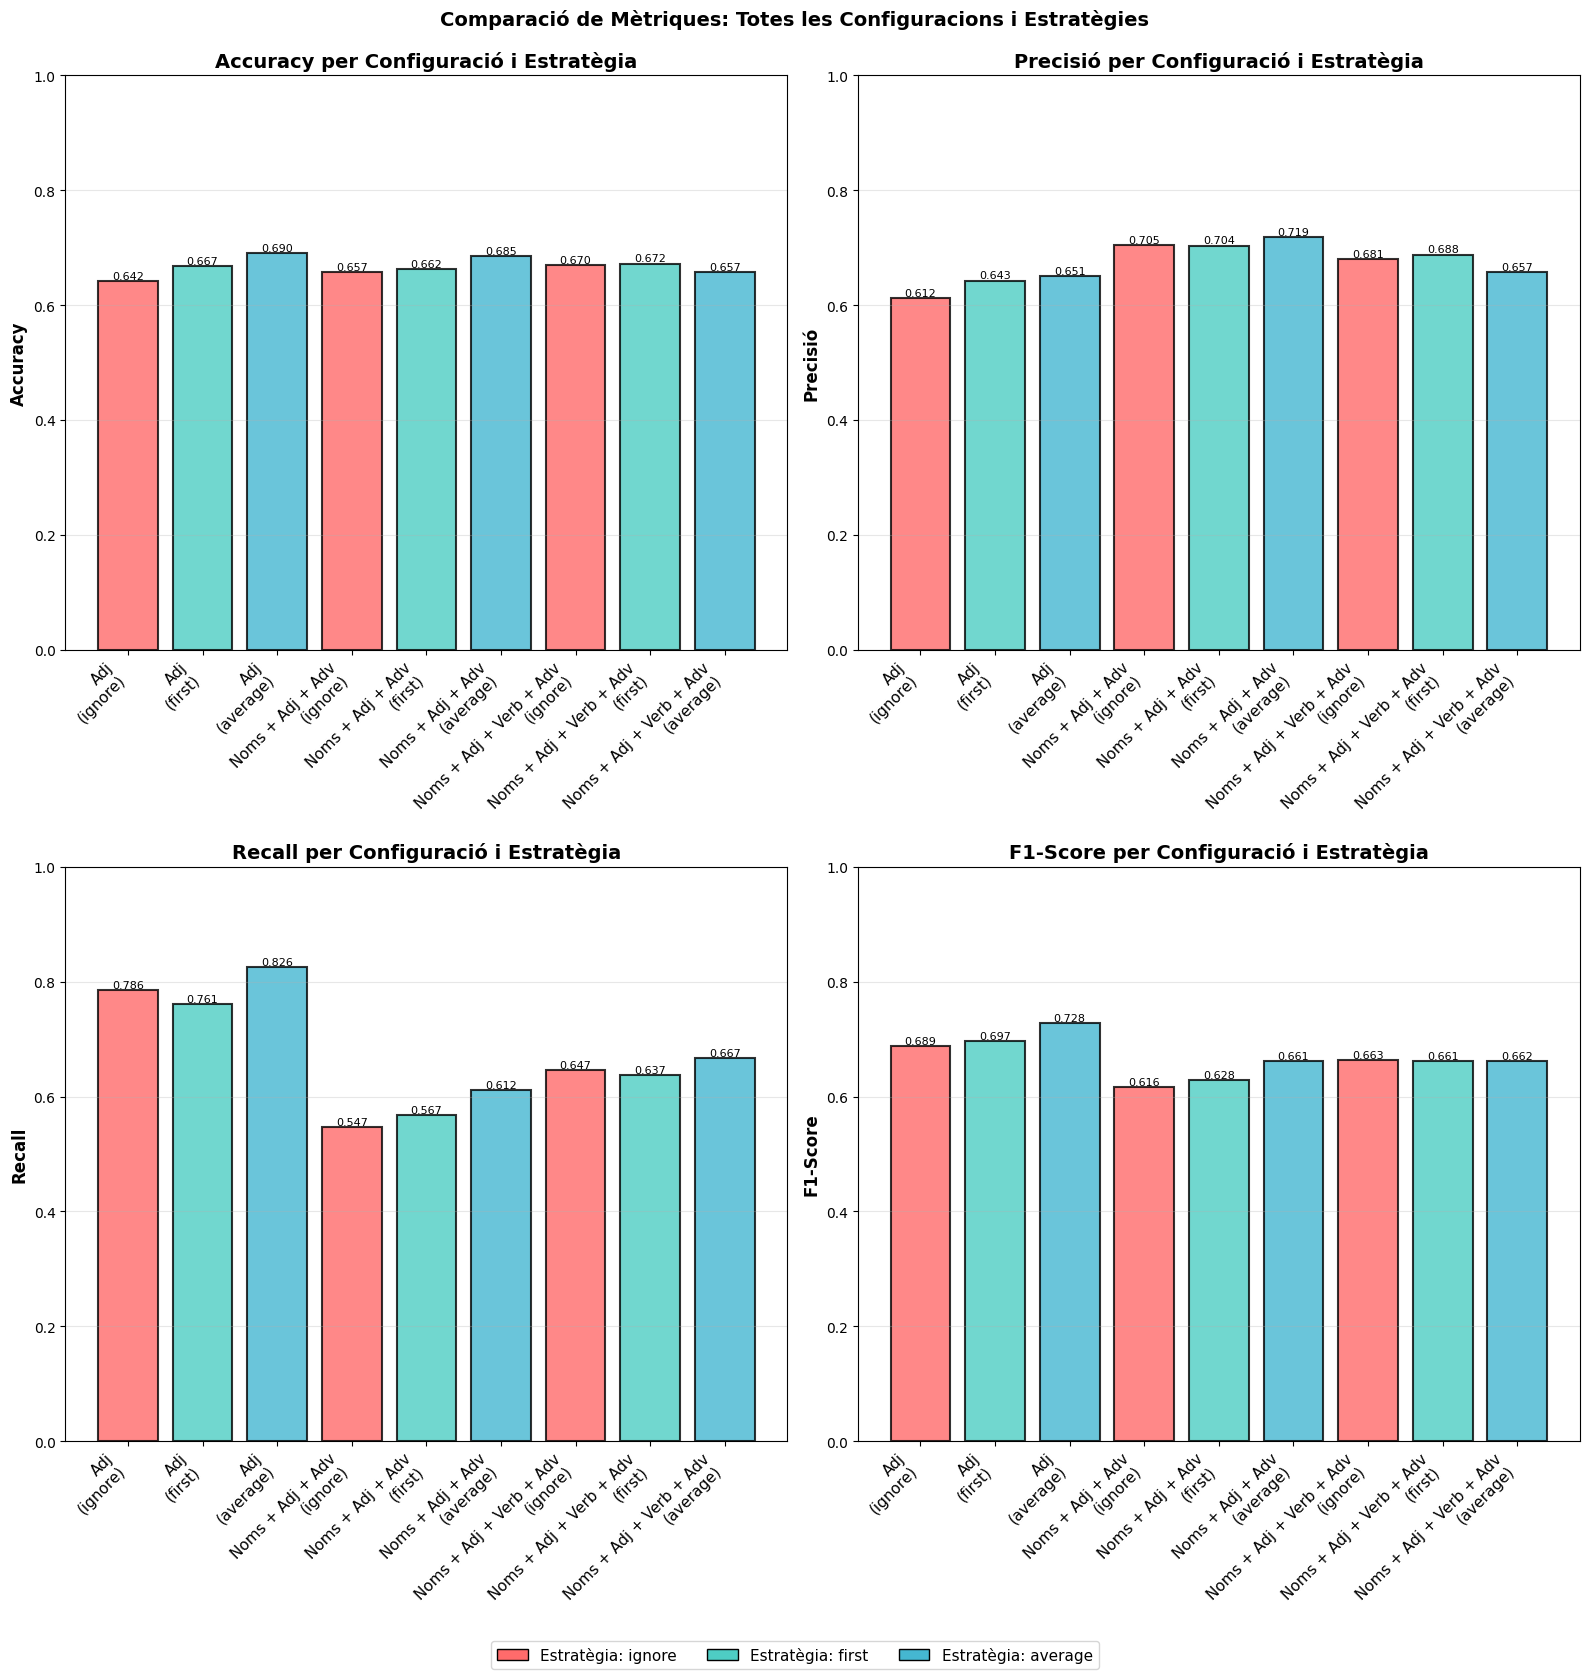

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TAULA RESUM: CONFIGURACIONS I ESTRATÈGIES NO SUPERVISADES")

data_rows = []

for config_name in pos_configs.keys():
    for strategy in strategies:
        if strategy in unsupervised_results[config_name]:
            result = unsupervised_results[config_name][strategy]
            data_rows.append({
                "Configuració": config_name,
                "Estratègia": strategy,
                "Accuracy": f"{result['accuracy']:.4f}",
                "Precisió": f"{result['precision']:.4f}",
                "Recall": f"{result['recall']:.4f}",
                "F1-Score": f"{result['f1']:.4f}",
                "AUC": f"{result['roc_auc']:.4f}"
            })

df_unsup = pd.DataFrame(data_rows)
print("\n" + df_unsup.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

metrics = ['Accuracy', 'Precisió', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    labels = [f"{row['Configuració']}\n({row['Estratègia']})" for _, row in df_unsup.iterrows()]
    values = [float(row[metric]) for _, row in df_unsup.iterrows()]
    
    colors = []
    for _, row in df_unsup.iterrows():
        if row['Estratègia'] == 'ignore':
            colors.append('#FF6B6B')
        elif row['Estratègia'] == 'first':
            colors.append('#4ECDC4')
        else:
            colors.append('#45B7D1')
    
    bars = ax.bar(range(len(labels)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} per Configuració i Estratègia', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Estratègia: ignore'),
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Estratègia: first'),
    Patch(facecolor='#45B7D1', edgecolor='black', label='Estratègia: average')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=11)

plt.suptitle('Comparació de Mètriques: Totes les Configuracions i Estratègies', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()


L'estratègia *average* és consistentment superior a *ignore* i *first* en gairebé totes les configuracions. Això suggereix que, en absència d'un desambiguador de qualitat, calcular la mitjana de tots els sentits possibles és una aproximació més robusta que confiar en Lesk, que pot fallar o escollir un sentit incorrecte quan el context és ambigu o el vocabulari cinematogràfic no encaixa bé amb les definicions de WordNet.

Pel que fa a les categories gramaticals, s'observen tres comportaments clarament diferenciats. La configuració *Adj* obté el millor F1-Score (0.728 amb *average*) i el millor recall (0.826), però a costa d'una precisió més baixa (0.651): el model tendeix a classificar moltes ressenyes com a positives. La configuració *Noms + Adj + Adv* presenta el comportament invers: aconsegueix la millor precisió (0.719 amb *average*), però el recall cau notablement fins a 0.612, el que indica que moltes ressenyes positives es classifiquen erròniament com a negatives. La configuració *Noms + Adj + Verb + Adv* se situa en un punt intermedi, amb recall i precisió més equilibrats, però sense superar clarament cap de les altres en F1-Score, i amb l'AUC més alta de totes (0.752 amb *average*), la qual cosa indica que, tot i no tenir el millor llindar de decisió binari, és el model que millor separa les dues classes en termes de rànquing.

### Matrius de confusió


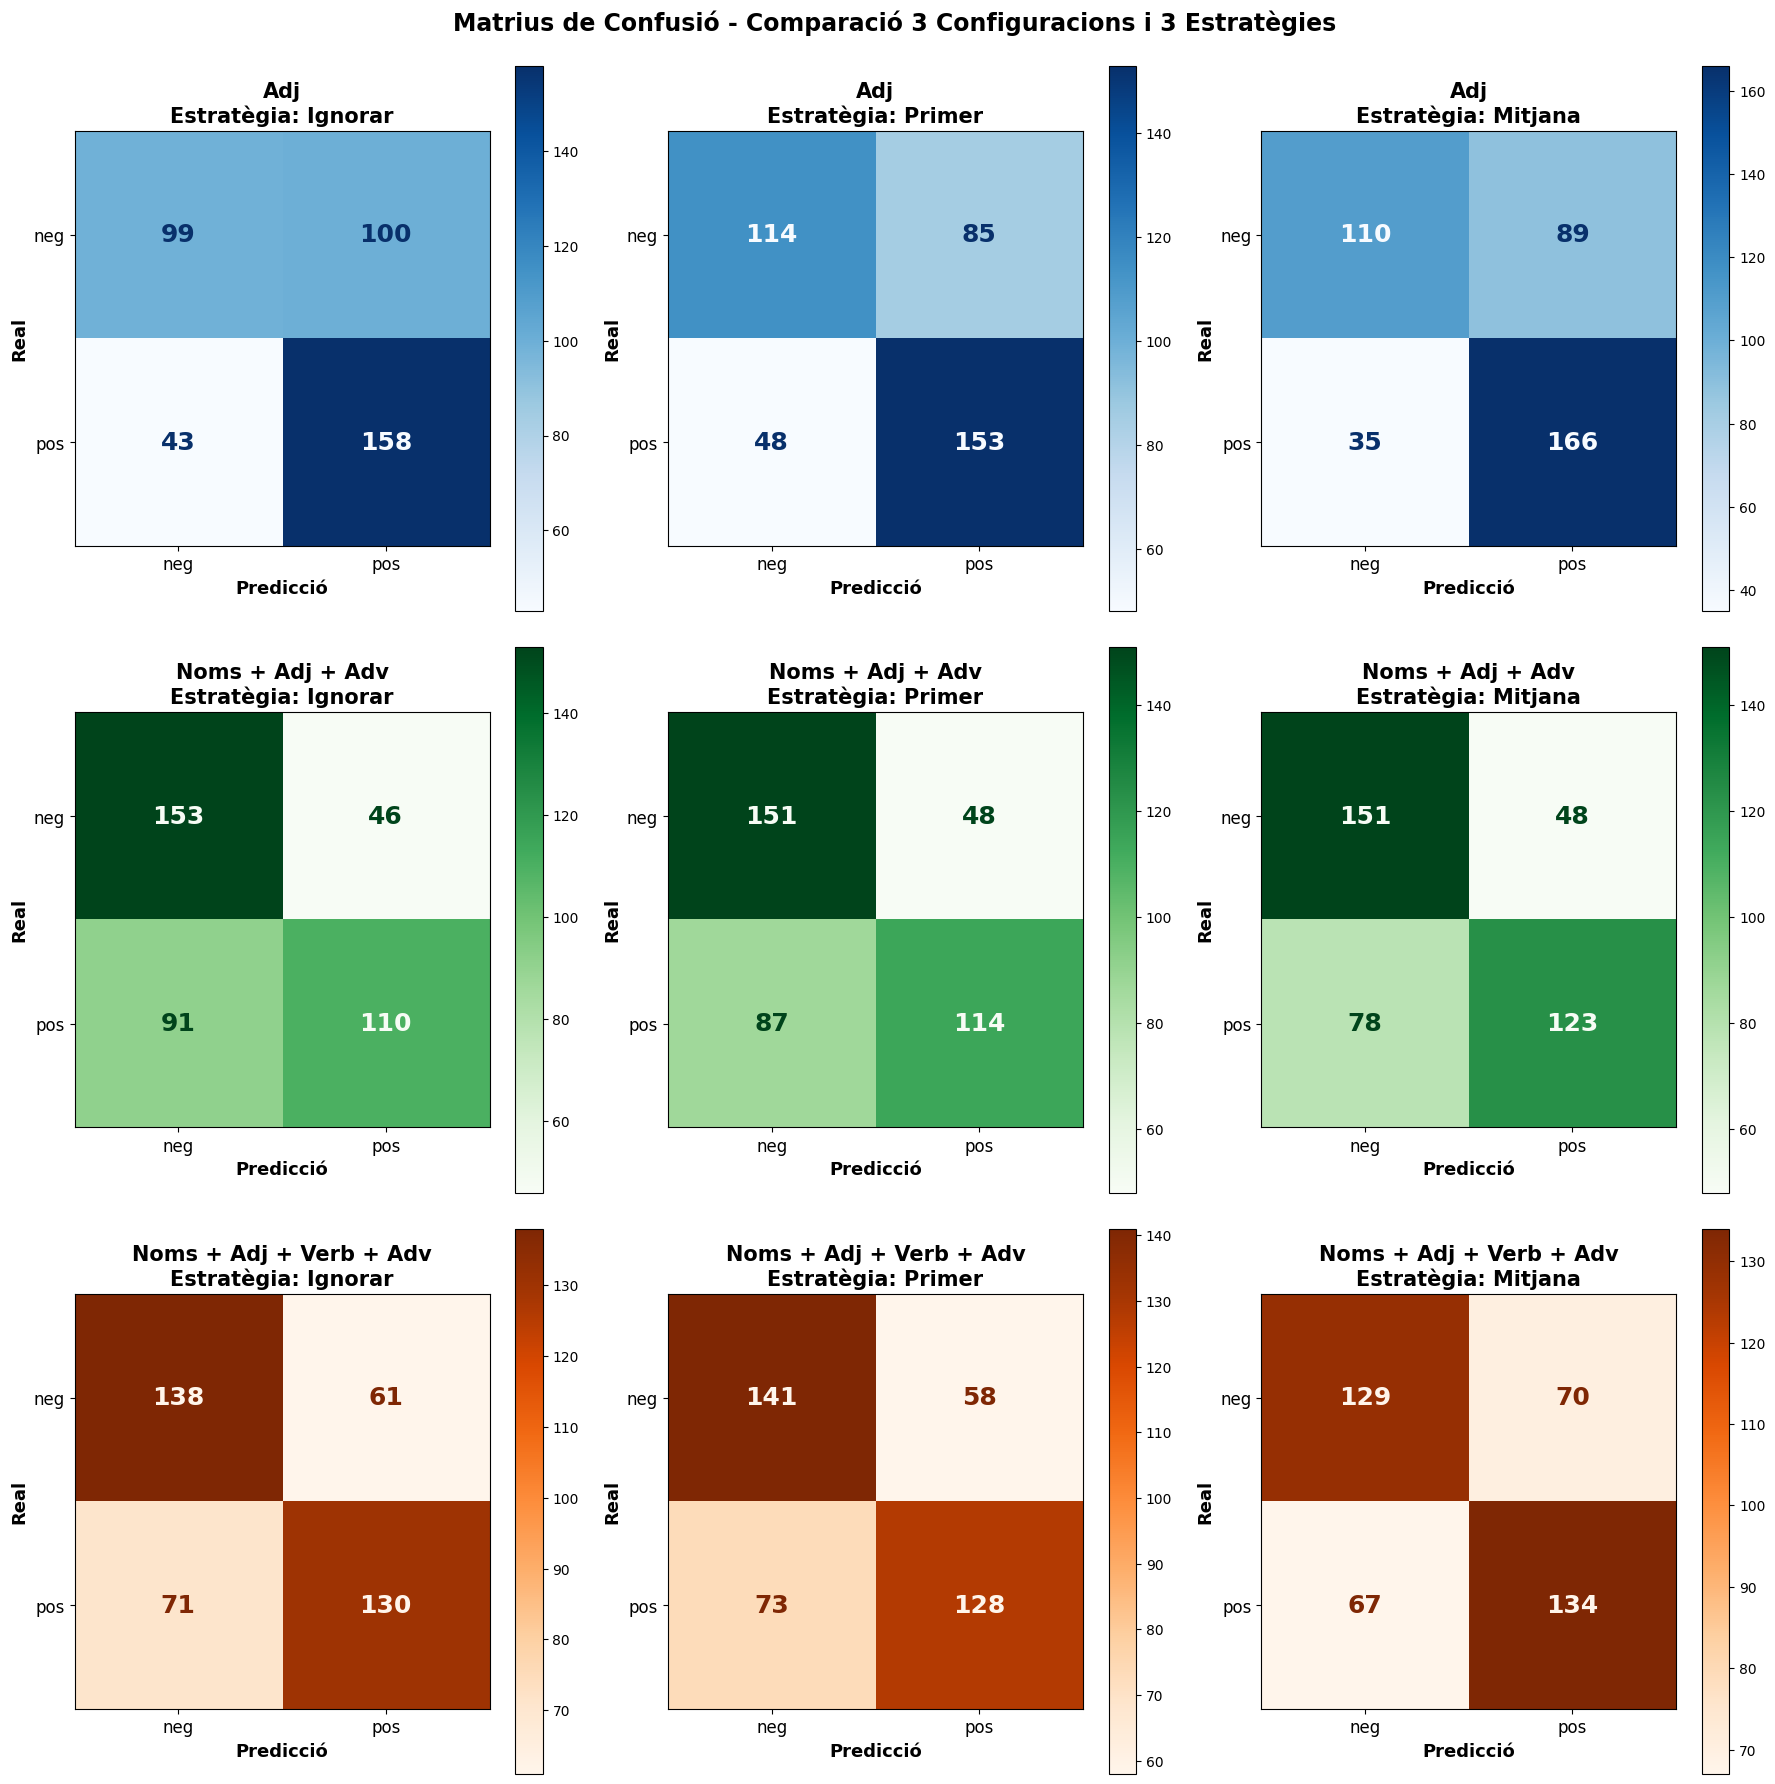

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Gráfico: 9 Matrices de Confusión en formato 3x3 (3 configuraciones × 3 estrategies)
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

configs = list(unsupervised_results.keys())
strategies = ["ignore", "first", "average"]
colors_list = ['Blues', 'Greens', 'Oranges']
strategy_names = {"ignore": "Ignorar", "first": "Primer", "average": "Mitjana"}

idx = 0
for config_idx, config_name in enumerate(configs):
    for strat_idx, strategy in enumerate(strategies):
        cm = unsupervised_results[config_name][strategy]['cm']
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
        disp.plot(cmap=colors_list[config_idx], ax=axes[idx], values_format='d')
        
        # Aumentar tamaño de fuente de los números en la matriz
        for text in axes[idx].texts:
            text.set_fontsize(18)
            text.set_weight('bold')
        
        # Títol amb configuració i estratègia
        title = f"{config_name}\nEstratègia: {strategy_names[strategy]}"
        axes[idx].set_title(title, fontsize=15, fontweight='bold')
        
        # Augmentar tamanys dels eixos
        axes[idx].set_xlabel("Predicció", fontsize=13, fontweight='bold')
        axes[idx].set_ylabel("Real", fontsize=13, fontweight='bold')
        axes[idx].tick_params(axis='both', labelsize=12)
        
        idx += 1

plt.suptitle('Matrius de Confusió - Comparació 3 Configuracions i 3 Estratègies', 
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


Les matrius de confusió permeten visualitzar amb més detall el biaix de cada configuració. En la configuració *Adj*, les tres estratègies classifiquen moltes ressenyes com a positives: amb *ignore*, hi ha 158 veritables positius però 43 falsos positius; amb *average*, els veritables positius pugen a 166 i els falsos positius baixen a 35, millorant notablement la precisió. En canvi, els falsos negatius (ressenyes positives classificades com a negatives) es mantenen elevats en totes les estratègies, cosa coherent amb un recall alt però no perfecte.

En la configuració *Noms + Adj + Adv*, el comportament s'inverteix clarament: el model ara tendeix a predir negatiu. Amb *ignore*, hi ha 153 veritables negatius però 91 falsos negatius, és a dir, moltes ressenyes positives que no es detecten. Amb *average* millora lleugerament, amb 151 veritables negatius i 78 falsos negatius, però el biaix cap a la classe negativa es manté. Això explica la precisió alta i el recall baix d'aquesta configuració.

La configuració *Noms + Adj + Verb + Adv* mostra un equilibri més gran entre els dos tipus d'error. Amb *ignore*, hi ha 138 veritables negatius i 71 falsos negatius, i 130 veritables positius i 61 falsos positius: els errors es distribueixen de manera més simètrica entre les dues classes, cosa que es reflecteix en la seva precisió i recall més properes entre si.



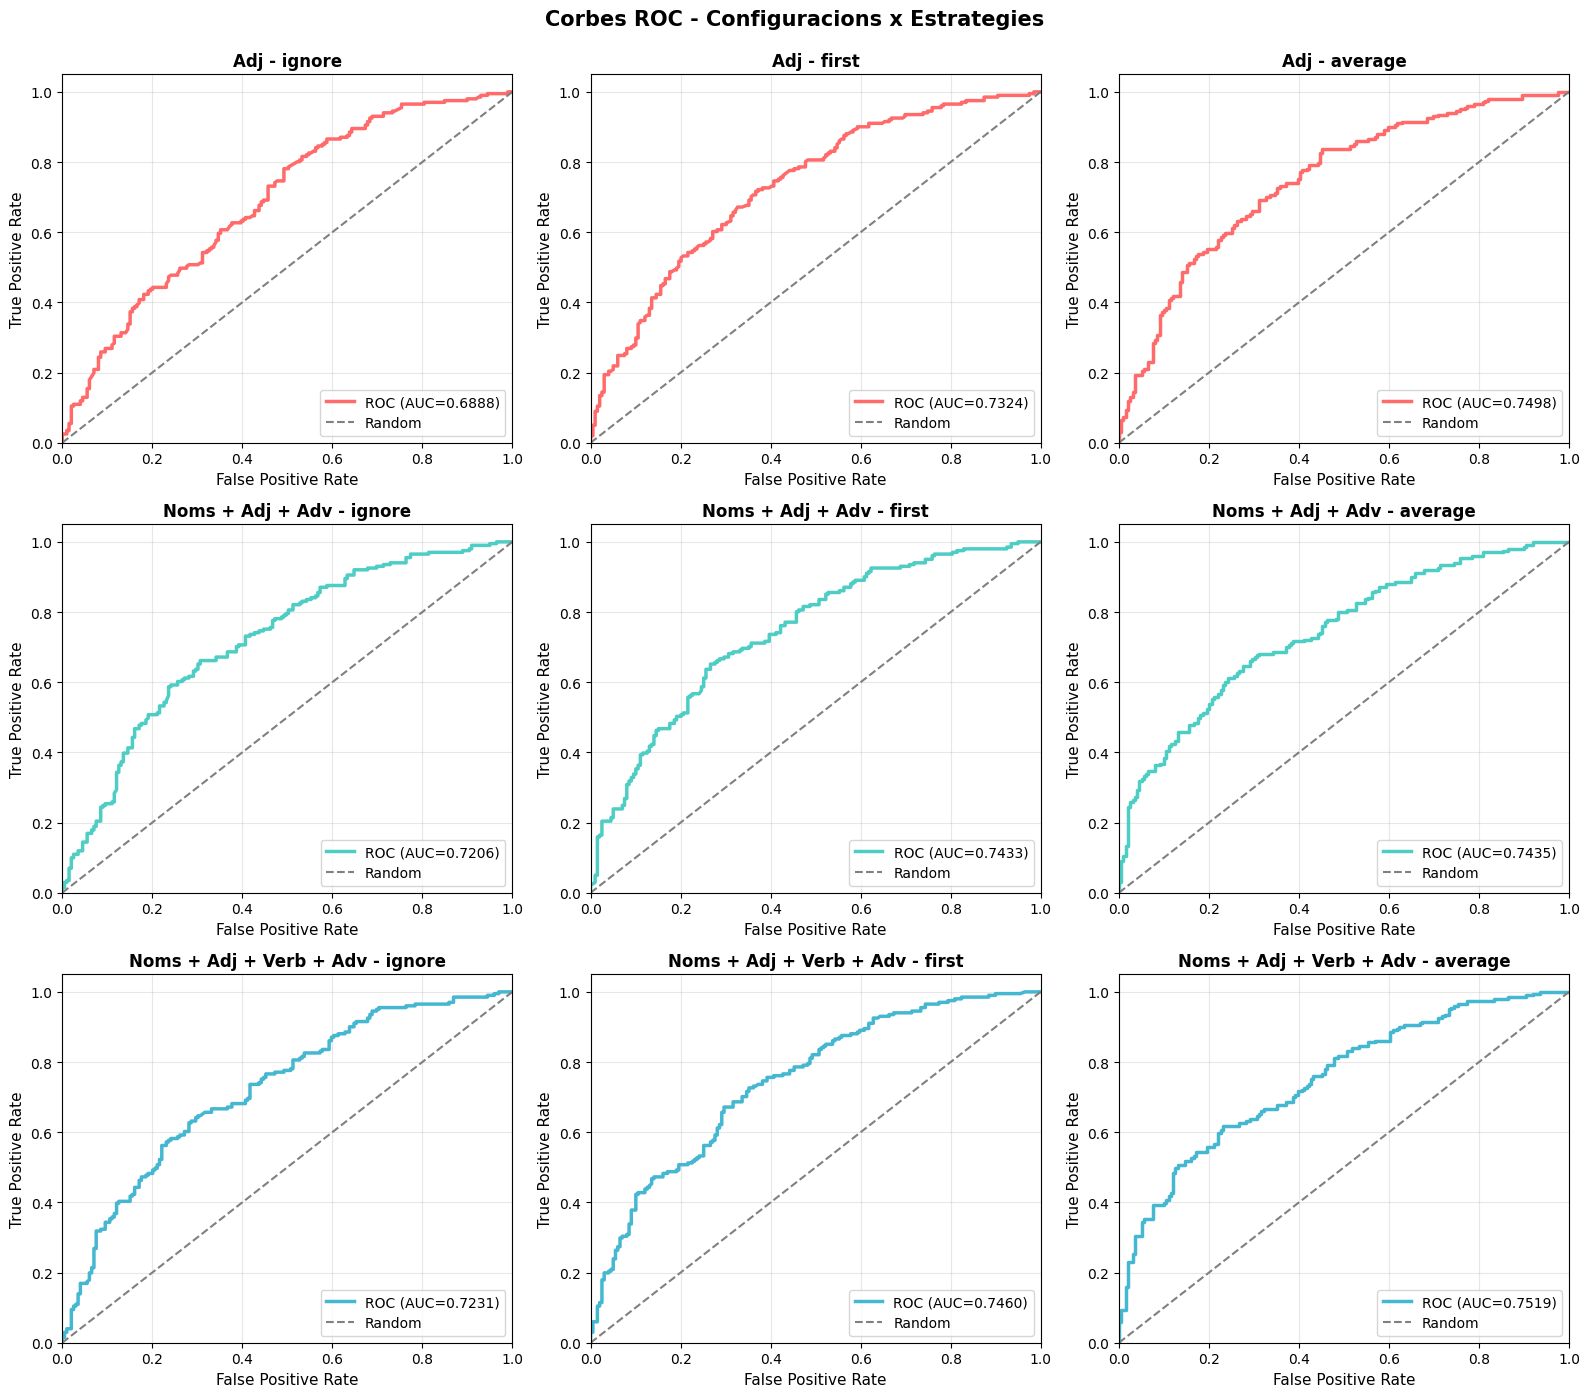

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(unsupervised_results), len(strategies), figsize=(16, 14))

configs = list(unsupervised_results.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for row, config_name in enumerate(configs):
    for col, strategy in enumerate(strategies):
        result = unsupervised_results[config_name][strategy]
        fpr = result['fpr']
        tpr = result['tpr']
        roc_auc = result['roc_auc']
        
        ax = axes[row, col]
        
        ax.plot(fpr, tpr, color=colors[row], lw=2.5, 
                label=f'ROC (AUC={roc_auc:.4f})')
        ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random')
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.set_title(f'{config_name} - {strategy}', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(alpha=0.3)

plt.suptitle('Corbes ROC - Configuracions x Estrategies', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Estadístiques de cobertura de synsets

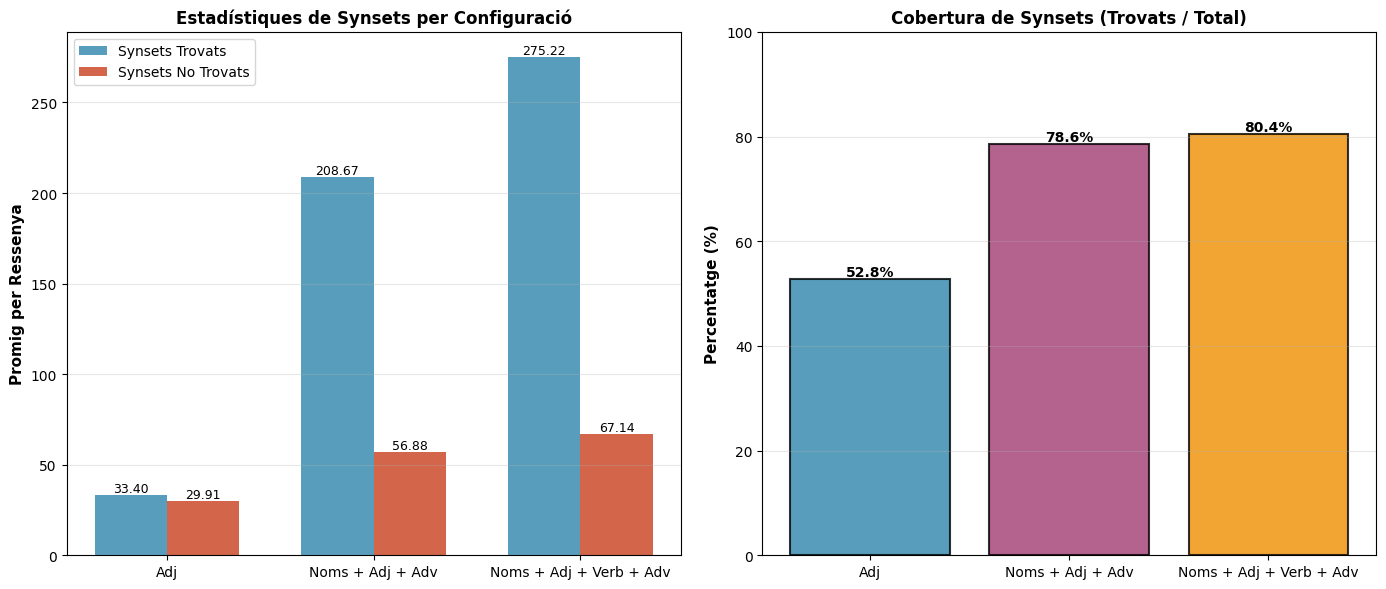


RESUM ESTADÍSTIQUES DE SYNSETS PER CONFIGURACIÓ

           Configuració Synsets Trovats (avg) Synsets No Trovats (avg) Cobertura (%)
                    Adj                 33.40                    29.91         52.8%
       Noms + Adj + Adv                208.67                    56.88         78.6%
Noms + Adj + Verb + Adv                275.22                    67.14         80.4%


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer estadísticas para cada configuración (usar la estrategia "ignore" ya que todas tienen las mismas)
configs = list(unsupervised_results.keys())
avg_found_list = []
avg_not_found_list = []
coverage_pct_list = []

for config_name in configs:
    stats = unsupervised_results[config_name]['ignore']['synsets_stats']  # Usar cualquier estrategia, todas son iguales
    avg_found = np.mean(stats["found"])
    avg_not_found = np.mean(stats["not_found"])
    avg_processed = np.mean(stats["processed"])
    
    # Calcular cobertura (porcentaje de synsets encontrados)
    if avg_processed > 0:
        coverage_pct = (avg_found / avg_processed) * 100
    else:
        coverage_pct = 0
    
    avg_found_list.append(avg_found)
    avg_not_found_list.append(avg_not_found)
    coverage_pct_list.append(coverage_pct)

# Crear gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Synsets trovados vs No encontrados
x = np.arange(len(configs))
width = 0.35

bars1 = axes[0].bar(x - width/2, avg_found_list, width, label='Synsets Trovats', color='#2E86AB', alpha=0.8)
bars2 = axes[0].bar(x + width/2, avg_not_found_list, width, label='Synsets No Trovats', color='#C73E1D', alpha=0.8)

axes[0].set_ylabel('Promig per Ressenya', fontsize=11, fontweight='bold')
axes[0].set_title('Estadístiques de Synsets per Configuració', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Afegir valors a les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Porcentaje de cobertura (synsets encontrados / total procesados)
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars3 = axes[1].bar(configs, coverage_pct_list, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('Percentatge (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Cobertura de Synsets (Trovats / Total)', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 100])
axes[1].grid(axis='y', alpha=0.3)

# Afegir valors percentuals
for bar in bars3:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Taula resum d'estadístiques
print("\nRESUM ESTADÍSTIQUES DE SYNSETS PER CONFIGURACIÓ")
print("="*80)

summary_data = {
    "Configuració": configs,
    "Synsets Trovats (avg)": [f"{x:.2f}" for x in avg_found_list],
    "Synsets No Trovats (avg)": [f"{x:.2f}" for x in avg_not_found_list],
    "Cobertura (%)": [f"{x:.1f}%" for x in coverage_pct_list]
}

df_stats = pd.DataFrame(summary_data)
print("\n" + df_stats.to_string(index=False))


La cobertura (entesa com el percentatge de paraules candidates per a les quals s'ha trobat un synset vàlid) és força alta en les tres configuracions un cop corregit el càlcul. La configuració *Adj* processa de mitjana 33 synsets per ressenya amb una cobertura del 52.8%, la qual cosa indica que aproximadament la meitat dels adjectius candidats troben un synset a SentiWordNet. La configuració *Noms + Adj + Adv* processa 209 synsets de mitjana amb una cobertura del 78.6%, i *Noms + Adj + Verb + Adv* arriba als 275 synsets i al 80.4%.

Aquests valors ajuden a entendre el comportament de cada configuració. La configuració *Adj* basa la seva puntuació en molt poques paraules però d'alta càrrega semàntica, cosa que genera puntuacions més extremes i un biaix cap al positiu: els adjectius de SentiWordNet tendeixen a tenir valors de sentiment marcats. En canvi, quan s'afegeixen noms, adverbis i verbs, la puntuació es calcula sobre moltes més paraules, moltes de les quals tenen valors neutres o lleugerament negatius a SentiWordNet, cosa que desplaça la puntuació agregada cap al negatiu i explica el biaix cap als falsos negatius que s'observa en les configuracions més àmplies.

### Millor model i conclusions

El millor model d'aquest apartat és la configuració **Adj + average**, amb una accuracy de 0.690, un F1-Score de 0.728 i un AUC de 0.750. És la configuració que millor equilibra els errors globals i la que obté el F1-Score més alt, tot i que presenta un biaix cap a les prediccions positives. Si el criteri fos maximitzar la precisió —per exemple, en un sistema on els falsos positius tinguessin un cost alt—, la millor opció seria *Noms + Adj + Adv + average* (precisió 0.719). I si el criteri fos maximitzar la capacitat discriminativa en termes de rànquing, *Noms + Adj + Verb + Adv + average* ofereix l'AUC més alta (0.752).

En qualsevol cas, els resultats globals se situen entre el 64% i el 69% d'accuracy, un rang raonable per a un sistema completament no supervisat que no ha vist cap exemple etiquetat i que opera exclusivament a partir de recursos lèxics externs.

## ANÁLISIS D'ERRORS: FRASES MAL CLASSIFICADES EN ELS MODELS

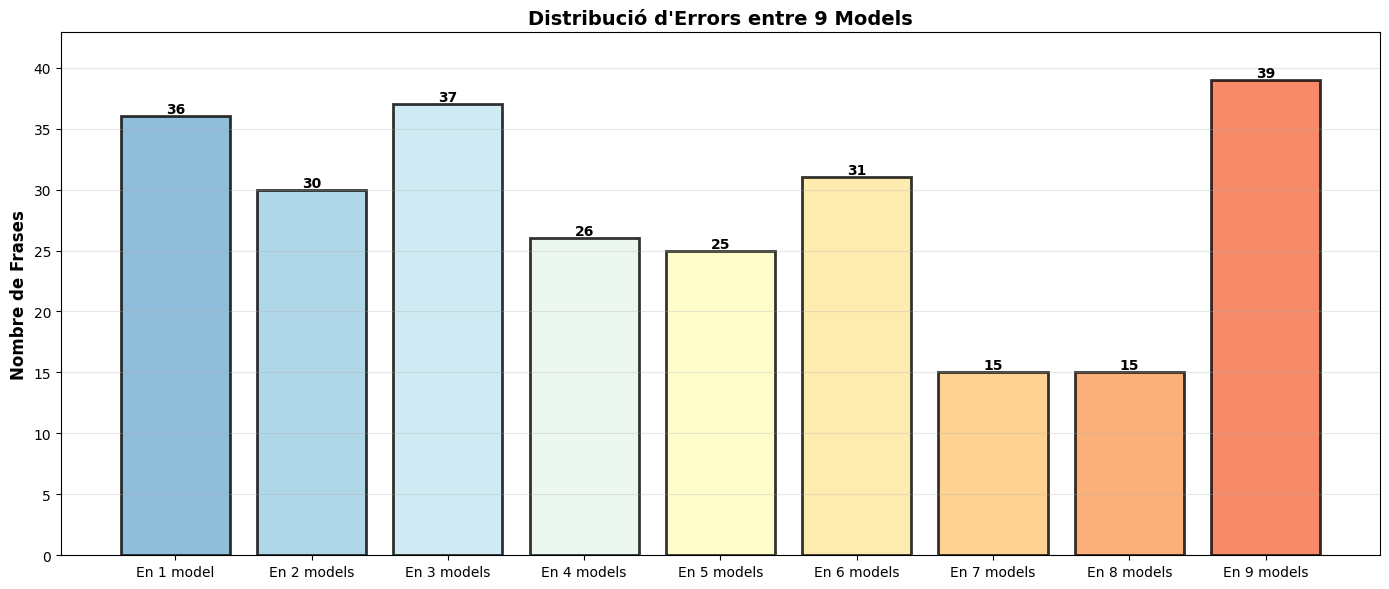

In [26]:
import matplotlib.pyplot as plt
import numpy as np

configs = list(unsupervised_results.keys())
total_models = len(configs) * len(strategies)

# Contar para cada frase en cuántos modelos falla
error_count = np.zeros(len(y_test_arr_ns))

for config_name in configs:
    for strategy in strategies:
        errors_mask = np.array(unsupervised_results[config_name][strategy]['errors_mask'])
        error_count += errors_mask.astype(int)

# Contar cuántas frases fallan en exactamente n modelos
errors_by_count = {}
for n in range(1, total_models + 1):
    errors_by_count[n] = np.sum(error_count == n)

# Crear gràfic
fig, ax = plt.subplots(figsize=(14, 6))

categories = [f"En {n} model{'s' if n > 1 else ''}" for n in range(1, total_models + 1)]
values = [errors_by_count[n] for n in range(1, total_models + 1)]
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, total_models))

bars = ax.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

ax.set_ylabel('Nombre de Frases', fontsize=12, fontweight='bold')
ax.set_title(f'Distribució d\'Errors entre {total_models} Models', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(values) + max(values)*0.1])
ax.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


Per aprofundir en les limitacions del model, s'ha analitzat amb quanta consistència els textos del conjunt de test eren mal classificats entre les nou configuracions. Per a cada text, es comptabilitza en quants models havia estat incorrectament classificat, obtenint la distribució següent: 36 textos van ser mal classificats per exactament 1 model, 30 per exactament 2, 37 per exactament 3, 26 per exactament 4, 25 per exactament 5, 31 per exactament 6, 15 per exactament 7, 15 per exactament 8, i finalment 39 textos van ser mal classificats per la totalitat dels nou models. Aquest darrer grup és especialment rellevant, ja que representa errors que no depenen de cap decisió de disseny concreta (ni de la tria de categories gramaticals ni de l'estratègia de desambiguació) sinó de limitacions estructurals del sistema.

##### ERRORS SITEMÀTICS (EXEMPLES MAL CLASSIFICATS EN ELS 9 MODELS)

In [27]:
from nltk.corpus import movie_reviews as mr
from sklearn.model_selection import train_test_split

# Cargar documentos originales y limpios
documents_original = []
documents_clean = []
labels_all = []

for categoria in mr.categories():
    for fileid in mr.fileids(categoria):
        raw_text = mr.raw(fileid)
        clean_text = clean_text_string(raw_text)
        
        if clean_text:
            documents_original.append(raw_text)
            documents_clean.append(clean_text)
            labels_all.append(categoria)

# Split amb el mateix random_state per alinear amb y_test_arr
X_train_orig, X_test_orig, X_train_clean, X_test_clean, y_train_split, y_test_split = train_test_split(
    documents_original, documents_clean, labels_all, 
    test_size=0.2, random_state=42
)

# Convertir y_test a array
y_test_split = np.array(y_test_split)

# Ara la funció funciona
def analizar_error(num_error):
    """
    Mostra la informació completa d'un error específic que falla en els 9 models.
    """
    
    configs = list(unsupervised_results.keys())
    
    errors_all_models = None
    for config_name in configs:
        for strategy in strategies:
            errors_mask = np.array(unsupervised_results[config_name][strategy]['errors_mask'])
            if errors_all_models is None:
                errors_all_models = errors_mask.copy()
            else:
                errors_all_models = errors_all_models & errors_mask
    
    errors_all_models = np.where(errors_all_models)[0]
    
    if num_error < 1 or num_error > len(errors_all_models):
        print(f"Error: El número ha d'estar entre 1 i {len(errors_all_models)}")
        return
    
    idx = errors_all_models[num_error - 1]
    
    actual = y_test_split[idx]
    text_original = X_test_orig[idx].replace('\n', ' ')
    text_clean = X_test_clean[idx]
    
    print(f"ERROR {num_error} (de {len(errors_all_models)} totals)")
    print(f"\nETIQUETA REAL: {actual.upper()}")
    
    print(f"\nTEXT ORIGINAL:")
    print(f"  {text_original}")
    
    print(f"\nTEXT PREPROCESSAT:")
    print(f"  {text_clean}")
    
    print(f"\nPREDICCIONS (9 MODELS):")
    print("-" * 120)
    
    for config_name in configs:
        print(f"\nConfiguració: {config_name}")
        for strategy in strategies:
            result = unsupervised_results[config_name][strategy]
            pred = result['y_pred'][idx]
            score = result['scores'][idx]
            print(f"  • Estratègia '{strategy:8s}' → Predicció: {pred:4s} | Puntuació: {score:7.4f}")

In [28]:
analizar_error(1)
analizar_error(2)
analizar_error(3)
analizar_error(4)
analizar_error(5)
analizar_error(6)
analizar_error(7)

ERROR 1 (de 39 totals)

ETIQUETA REAL: POS

TEXT ORIGINAL:
  the verdict : spine-chilling drama from horror maestro stephen king , featuring an outstanding , oscar-winning performance from kathy bates .  geez , french and saunders had a field day when they set to work on parodying this !  sorry , non-british readers may not be familiar with french and saunders - my apologies .  the pair are british comediennes ( jennifer saunders later went on to become edina monsoon in " absolutely fabulous " ) , who did a series of film spoofs a few years back , including alien , the exorcist and misery .  needless to say , amidst her chucklesome impersonation of kathy bates ( the resemblance was quite uncanny ! ) , dawn french got pretty nasty with her sledgehammer when in reach of jennifer saunder's legs !  but despite the lingering memory of their sketch , and although i've now seen the film a couple of times now , that " hobbling " scene was no less disturbing !  i'm still left screaming at the t

L'anàlisi d'aquests errors sistemàtics posa de manifest dos patrons principals. D'una banda, hi ha ressenyes positives classificades com a negatives: les puntuacions de totes les configuracions són lleugerament negatives (valors al voltant de -0.006 a -0.130), cosa que indica que el text conté paraules que SentiWordNet associa amb negativitat malgrat que el to general de la ressenya sigui favorable. Això pot ocórrer en ressenyes que discuteixen aspectes negatius de la pel·lícula per contrastar-los amb una valoració final positiva, o que utilitzen un registre irònic o crític que el sistema no sap interpretar. D'altra banda, hi ha ressenyes negatives classificades com a positives: el vocabulari superficialment positiu (adjectius com "great" o "wonderful" usats en frases negades o en contextos sarcàstics) dona una puntuació neta positiva que el model no pot corregir perquè no disposa de cap mecanisme per detectar la negació ni la ironia.

Aquest darrer punt (la incapacitat de gestionar les negacions) representa una limitació estructural del model base. Expressions com "not good" o "never enjoyable" s'interpreten exclusivament a partir del mot positiu ("good", "enjoyable"), invertint el sentiment real de la frase. Aquesta observació motiva directament l'extensió del model que es presenta a continuació.


## Segon model no supervisat: tractament de negacions

### Motivació i enfocament

L'anàlisi d'errors del model base va posar en evidència que una part important dels errors sistemàtics provenia de ressenyes on el sentiment real estava invertit per una negació. Expressions com *"not good"* o *"never enjoyable"* eren interpretades pel model exclusivament a partir del mot de sentiment (*"good"*, *"enjoyable"*), ignorant completament la negació que el precedeix. Per abordar aquesta limitació, s'ha dissenyat una extensió del model que incorpora un mecanisme explícit de detecció i propagació de negacions.

La idea és conceptualment senzilla: quan una paraula de sentiment apareix dins d'una finestra de tres tokens a la dreta d'una negació (*"not"*, *"no"*, *"never"*, *"neither"*, *"nor"*), la seva puntuació de sentiment s'inverteix de signe. Així, *"not good"* contribueix negativament a la puntuació total en lloc de positivament. Aquesta aproximació, coneguda a la literatura com a *negation window*, és un dels mecanismes més habituals en sistemes de sentiment basats en lèxic, i representa un pas cap a una comprensió mínima de l'estructura sintàctica sense necessitat de parsers complexos.

### Implementació

El preprocessament del text s'ha adaptat en la funció clean_text_string_not, que segueix el mateix pipeline que la versió anterior —tokenització, etiquetatge POS, eliminació de paraules buides i lematització— però hi afegeix una capa de marcatge de negació. A diferència d'aproximacions basades en una finestra fixa de tokens, aquí s'ha optat per un mecanisme sintàcticament més precís: la negació es propaga únicament seguint el patró NOT [ADV]* ADJ, és a dir, s'aplica a l'adjectiu immediat que segueix la negació, permetent que hi hagi adverbis modificadors entremig ("not very good", "not particularly interesting"). Tant l'adverbi com l'adjectiu de la seqüència queden marcats amb el prefix NOT_. Si el token que segueix la negació no és ni un adverbi ni un adjectiu, la cadena de negació es cancel·la immediatament, evitant que la inversió de signe es propagui a paraules semànticament no relacionades.

La funció de puntuació `sentiment_score_unsupervised_wsd_not` és funcionalment idèntica a la del model base, amb una única diferència: en el moment d'acumular la puntuació d'un token, es comprova si porta el prefix `NOT_`. En cas afirmatiu, la puntuació del synset s'inverteix de signe abans de sumar-se al total. La resta de la lògica —desambiguació amb Lesk, estratègies *ignore*, *first* i *average*, normalització final— es manté sense canvis, la qual cosa permet una comparació directa i equitativa entre ambdós models.


In [29]:

import re
import numpy as np
import nltk

from nltk.corpus import stopwords, wordnet as wn, sentiwordnet as swn
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.wsd import lesk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc, classification_report
)


In [30]:
for recurs in ["punkt", "stopwords", "wordnet", "averaged_perceptron_tagger",
               "sentiwordnet", "punkt_tab", "movie_reviews"]:
    nltk.download(recurs, quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
NEGACIONS = {"not", "no", "never", "neither", "nor"}

In [31]:
def penn_to_wn(tag: str):
    """Converteix etiquetes Penn Treebank a etiquetes POS de WordNet."""
    if tag.startswith("J"): return wn.ADJ
    if tag.startswith("V"): return wn.VERB
    if tag.startswith("N"): return wn.NOUN
    if tag.startswith("R"): return wn.ADV
    return None

WN_TAG_MAP = {
    wn.ADJ:  "ADJ",
    wn.VERB: "VERB",
    wn.NOUN: "NOUN",
    wn.ADV:  "ADV"
}

LABEL_TO_WN = {v: k for k, v in WN_TAG_MAP.items()}

In [32]:
def clean_text_string_not(text: str) -> str:
    """
    Neteja el text, lematitza amb POS correcte i marca negacions.
    Format de sortida: 'word/POS' o 'NOT_word/POS'

    La negació s'aplica únicament a l'adjectiu immediat, permetent
    adverbis intermedis: "not [ADV]* ADJ" → NOT_ADJ (i NOT_ADV si n'hi ha).
    """
    text = text.lower()

    tokens = word_tokenize(text)
    tokens = ["not" if t == "n't" else t for t in tokens]

    tagged_tokens = pos_tag(tokens)

    cleaned_tokens = []
    negation_active = False  # Estem dins d'una seqüència not [ADV]* ?

    for idx, (word, pos) in enumerate(tagged_tokens):

        # Si és una negació, activem el flag i la saltem
        if word in NEGACIONS:
            negation_active = True
            continue

        if word in stop_words or len(word) <= 1:
            continue

        word_clean = re.sub(r"[^a-z']", "", word)
        if not word_clean:
            continue

        wn_pos = penn_to_wn(pos)
        lemma = lemmatizer.lemmatize(word_clean, pos=wn_pos if wn_pos else wn.NOUN)
        pos_label = WN_TAG_MAP.get(wn_pos, "OTHER")

        if negation_active:
            if pos_label == "ADV":
                # Adverbi modificador: el marquem i continuem esperant l'adjectiu
                cleaned_tokens.append(f"NOT_{lemma}/{pos_label}")
            elif pos_label == "ADJ":
                # Adjectiu negat: el marquem i desactivem la negació
                cleaned_tokens.append(f"NOT_{lemma}/{pos_label}")
                negation_active = False
            else:
                # Qualsevol altra categoria trenca la cadena de negació
                negation_active = False
                cleaned_tokens.append(f"{lemma}/{pos_label}")
        else:
            cleaned_tokens.append(f"{lemma}/{pos_label}")

    return " ".join(cleaned_tokens)

In [33]:
from nltk.corpus import movie_reviews as mr

documents_not   = []
labels_all      = []

for categoria in mr.categories():
    for fileid in mr.fileids(categoria):
        raw_text   = mr.raw(fileid)
        clean_not  = clean_text_string_not(raw_text)

        if clean_not:
            documents_not.append(clean_not)
            labels_all.append(categoria)

# Un sol split — mateix random_state garanteix comparació justa entre models

X_train_not, X_test_not, \
y_train_not, y_test_not = train_test_split(
    documents_not, labels_all,
    test_size=0.2, random_state=42
)


print(f"Train: {len(X_train_not)} mostres | Test: {len(X_test_not)} mostres")

Train: 1600 mostres | Test: 400 mostres


In [34]:
def _score_synset(synset) -> float | None:
    """Retorna la puntuació de sentiment d'un synset o None si no existeix."""
    try:
        swn_synset = swn.senti_synset(synset.name())
        return swn_synset.pos_score() - swn_synset.neg_score()
    except Exception:
        return None

def sentiment_score_unsupervised_wsd_not(
    clean_text: str,
    pos_categories: list = ["ADJ"],
    strategy: str = "ignore"
) -> tuple:
    tokens_with_pos = clean_text.split()

    context_tokens = [
        t.rsplit("/", 1)[0].replace("NOT_", "")
        for t in tokens_with_pos if "/" in t
    ]

    total_score = 0.0
    synsets_found = 0
    synsets_not_found = 0

    for token in tokens_with_pos:
        if "/" not in token:
            continue

        word, pos_label = token.rsplit("/", 1)

        # Extreure prefix de negació abans de filtrar
        negated = word.startswith("NOT_")
        if negated:
            word = word[4:]

        # Tokens fora de les categories simplement s'ignoren, no es compten
        if pos_label == "OTHER" or pos_label not in pos_categories:
            continue

        wn_tag = LABEL_TO_WN.get(pos_label)
        if wn_tag is None:
            continue

        score = None

        if strategy in ("ignore", "first"):
            synset = lesk(context_tokens, word, pos=wn_tag)
            if synset is None and strategy == "first":
                synsets_list = wn.synsets(word, pos=wn_tag)
                synset = synsets_list[0] if synsets_list else None
            if synset:
                score = _score_synset(synset)

        elif strategy == "average":
            synsets_list = wn.synsets(word, pos=wn_tag)
            scores_list = [s for syn in synsets_list
                           if (s := _score_synset(syn)) is not None]
            if scores_list:
                score = float(np.mean(scores_list))

        if score is not None:
            total_score += -score if negated else score
            synsets_found += 1
        else:
            synsets_not_found += 1

    normalized_score = total_score / synsets_found if synsets_found > 0 else 0.0
    return normalized_score, synsets_found, synsets_not_found

In [35]:

# Combinacions de categories POS que volem avaluar
pos_configs = {
    "ADJ": ["ADJ"],
    "NOUN+ADJ+ADV": ["ADJ", "ADV"],
    "ADJ+ADV+VERB+NOUN": ["ADJ", "ADV", "VERB", "NOUN"],
}

strategies = ["ignore", "first", "average"]

In [36]:
unsupervised_results_not = {}
y_test_arr_not = np.array(y_test_not)

for config_name, pos_list in pos_configs.items():
    unsupervised_results_not[config_name] = {}

    for strategy in strategies:
        print(f"\nConfiguració: {config_name} | Estratègia: {strategy}")

        scores, found_list, not_found_list = [], [], []

        for text in X_test_not:
            score, found, not_found = sentiment_score_unsupervised_wsd_not(
                text,
                pos_categories=pos_list,
                strategy=strategy
            )
            scores.append(score)
            found_list.append(found)
            not_found_list.append(not_found)

        scores_arr = np.array(scores)

        # Comprovació de debugging: si tots els scores són 0 avisem
        non_zero = np.sum(scores_arr != 0)
        print(f"  [DEBUG] Scores no zero: {non_zero}/{len(scores_arr)}")

        # Classificació binària: positiu si score > 0
        y_pred = np.where(scores_arr > 0, "pos", "neg")

        # Mètriques d'avaluació
        accuracy  = accuracy_score(y_test_not, y_pred)
        precision = precision_score(y_test_not, y_pred, pos_label="pos", zero_division=0)
        recall    = recall_score(y_test_not, y_pred, pos_label="pos", zero_division=0)
        f1        = f1_score(y_test_not, y_pred, pos_label="pos", zero_division=0)
        cm        = confusion_matrix(y_test_not, y_pred)

        # Corba ROC
        y_test_bin  = (y_test_arr_not == "pos").astype(int)
        scores_norm = (scores_arr - scores_arr.min()) / (scores_arr.max() - scores_arr.min() + 1e-10)
        fpr, tpr, _ = roc_curve(y_test_bin, scores_norm)
        roc_auc     = auc(fpr, tpr)

        errors_mask   = y_pred != y_test_arr_not
        error_indices = np.where(errors_mask)[0]

        unsupervised_results_not[config_name][strategy] = {
            "pos_list":      pos_list,
            "scores":        scores_arr,
            "y_pred":        y_pred,
            "accuracy":      accuracy,
            "precision":     precision,
            "recall":        recall,
            "f1":            f1,
            "cm":            cm,
            "synsets_stats": {
                "found":     found_list,
                "not_found": not_found_list,
                "processed": [f + nf for f, nf in zip(found_list, not_found_list)]
            },
            "fpr":           fpr,
            "tpr":           tpr,
            "roc_auc":       roc_auc,
            "errors_mask":   errors_mask,
            "error_indices": error_indices,
            "num_errors":    int(np.sum(errors_mask))
        }

        print(f"  - Accuracy: {accuracy:.3f} | F1: {f1:.3f} | AUC: {roc_auc:.3f}")


Configuració: ADJ | Estratègia: ignore
  [DEBUG] Scores no zero: 388/400
  - Accuracy: 0.608 | F1: 0.661 | AUC: 0.673

Configuració: ADJ | Estratègia: first
  [DEBUG] Scores no zero: 398/400
  - Accuracy: 0.650 | F1: 0.692 | AUC: 0.728

Configuració: ADJ | Estratègia: average
  [DEBUG] Scores no zero: 400/400
  - Accuracy: 0.690 | F1: 0.728 | AUC: 0.736

Configuració: NOUN+ADJ+ADV | Estratègia: ignore
  [DEBUG] Scores no zero: 396/400
  - Accuracy: 0.598 | F1: 0.686 | AUC: 0.675

Configuració: NOUN+ADJ+ADV | Estratègia: first
  [DEBUG] Scores no zero: 395/400
  - Accuracy: 0.635 | F1: 0.703 | AUC: 0.727

Configuració: NOUN+ADJ+ADV | Estratègia: average
  [DEBUG] Scores no zero: 400/400
  - Accuracy: 0.637 | F1: 0.711 | AUC: 0.733

Configuració: ADJ+ADV+VERB+NOUN | Estratègia: ignore
  [DEBUG] Scores no zero: 400/400
  - Accuracy: 0.578 | F1: 0.676 | AUC: 0.689

Configuració: ADJ+ADV+VERB+NOUN | Estratègia: first
  [DEBUG] Scores no zero: 398/400
  - Accuracy: 0.605 | F1: 0.687 | AUC: 

### Anàlisi dels resultats

#### Mètriques globals

La taula següent recull els resultats de les nou configuracions del model amb tractament de negacions:

TAULA RESUM: CONFIGURACIONS I ESTRATÈGIES NO SUPERVISADES

     Configuració Estratègia Accuracy Precisió Recall F1-Score    AUC
              ADJ     ignore   0.6075   0.5840 0.7612   0.6609 0.6728
              ADJ      first   0.6500   0.6206 0.7811   0.6916 0.7284
              ADJ    average   0.6900   0.6510 0.8259   0.7281 0.7364
     NOUN+ADJ+ADV     ignore   0.5975   0.5641 0.8756   0.6862 0.6748
     NOUN+ADJ+ADV      first   0.6350   0.5945 0.8607   0.7033 0.7270
     NOUN+ADJ+ADV    average   0.6375   0.5933 0.8856   0.7106 0.7333
ADJ+ADV+VERB+NOUN     ignore   0.5775   0.5500 0.8756   0.6756 0.6895
ADJ+ADV+VERB+NOUN      first   0.6050   0.5710 0.8607   0.6865 0.7227
ADJ+ADV+VERB+NOUN    average   0.5700   0.5441 0.8905   0.6755 0.7263


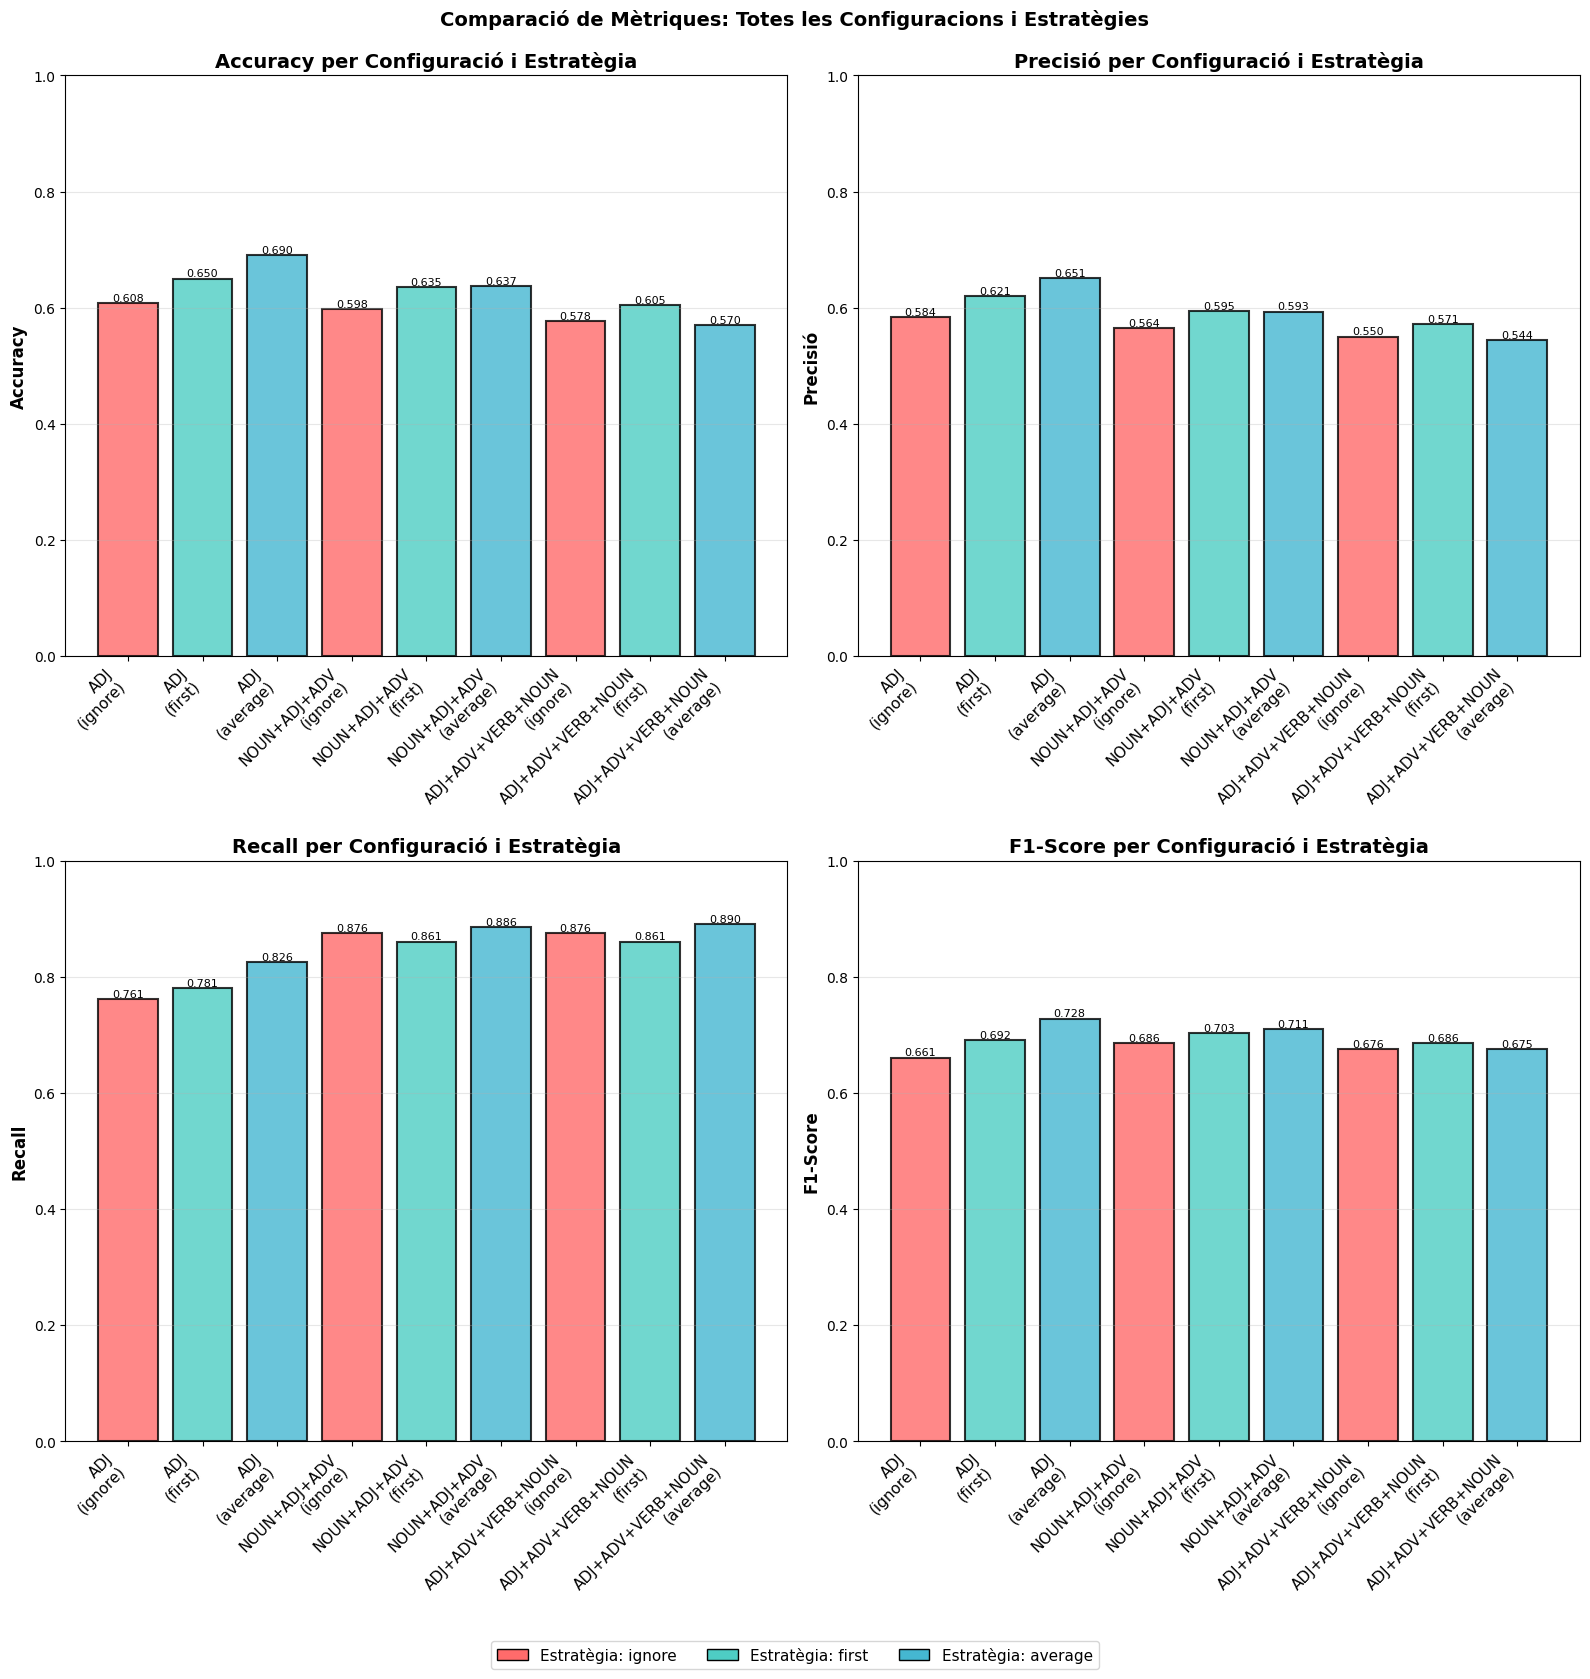

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TAULA RESUM: CONFIGURACIONS I ESTRATÈGIES NO SUPERVISADES")
print("="*80)

data_rows_not = []

for config_name in pos_configs.keys():
    for strategy in strategies:
        if strategy in unsupervised_results_not[config_name]:
            result_not = unsupervised_results_not[config_name][strategy]
            data_rows_not.append({
                "Configuració": config_name,
                "Estratègia": strategy,
                "Accuracy": f"{result_not['accuracy']:.4f}",
                "Precisió": f"{result_not['precision']:.4f}",
                "Recall": f"{result_not['recall']:.4f}",
                "F1-Score": f"{result_not['f1']:.4f}",
                "AUC": f"{result_not['roc_auc']:.4f}"
            })

df_unsup_not = pd.DataFrame(data_rows_not)
print("\n" + df_unsup_not.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

metrics = ['Accuracy', 'Precisió', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    labels = [f"{row['Configuració']}\n({row['Estratègia']})" for _, row in df_unsup_not.iterrows()]
    values = [float(row[metric]) for _, row in df_unsup_not.iterrows()]

    
    colors = []
    for _, row in df_unsup_not.iterrows():
        if row['Estratègia'] == 'ignore':
            colors.append('#FF6B6B')
        elif row['Estratègia'] == 'first':
            colors.append('#4ECDC4')
        else:
            colors.append('#45B7D1')
    
    bars = ax.bar(range(len(labels)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} per Configuració i Estratègia', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
    ax.set_ylim([0, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Estratègia: ignore'),
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Estratègia: first'),
    Patch(facecolor='#45B7D1', edgecolor='black', label='Estratègia: average')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=11)

plt.suptitle('Comparació de Mètriques: Totes les Configuracions i Estratègies', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

El primer que s'observa és que el tractament de negacions **no millora els resultats globals** respecte al model base, sinó que en la majoria de configuracions els empitjora. La configuració *ADJ + average* és l'única que manté un rendiment comparable (accuracy 0.690, F1 0.728), mentre que *NOUN+ADJ+ADV* i *ADJ+ADV+VERB+NOUN* experimenten caigudes notables en accuracy i precisió.

El patró dominant en aquest model és un **recall molt alt acompanyat d'una precisió baixa** a totes les configuracions excepte *ADJ*. Els recalls arriben fins a 0.886 i 0.891, però les precisions cauen fins a 0.544-0.594, molt per sota dels valors del model base. Això indica que el model tendeix a classificar la gran majoria de ressenyes com a positives, independentment de la configuració, un biaix que el tractament de negacions no només no corregeix sinó que en alguns casos accentua.

Pel que fa a l'estratègia, *average* continua sent la millor en la configuració *ADJ*, però en les altres dues configuracions el comportament és menys clar: *average* no supera sistemàticament *first* ni en F1-Score ni en accuracy, a diferència del que passava en el model base. L'AUC més alta la obté *ADJ + average* (0.736), però en general els valors d'AUC són inferiors als del model base en totes les configuracions.

#### Matrius de confusió


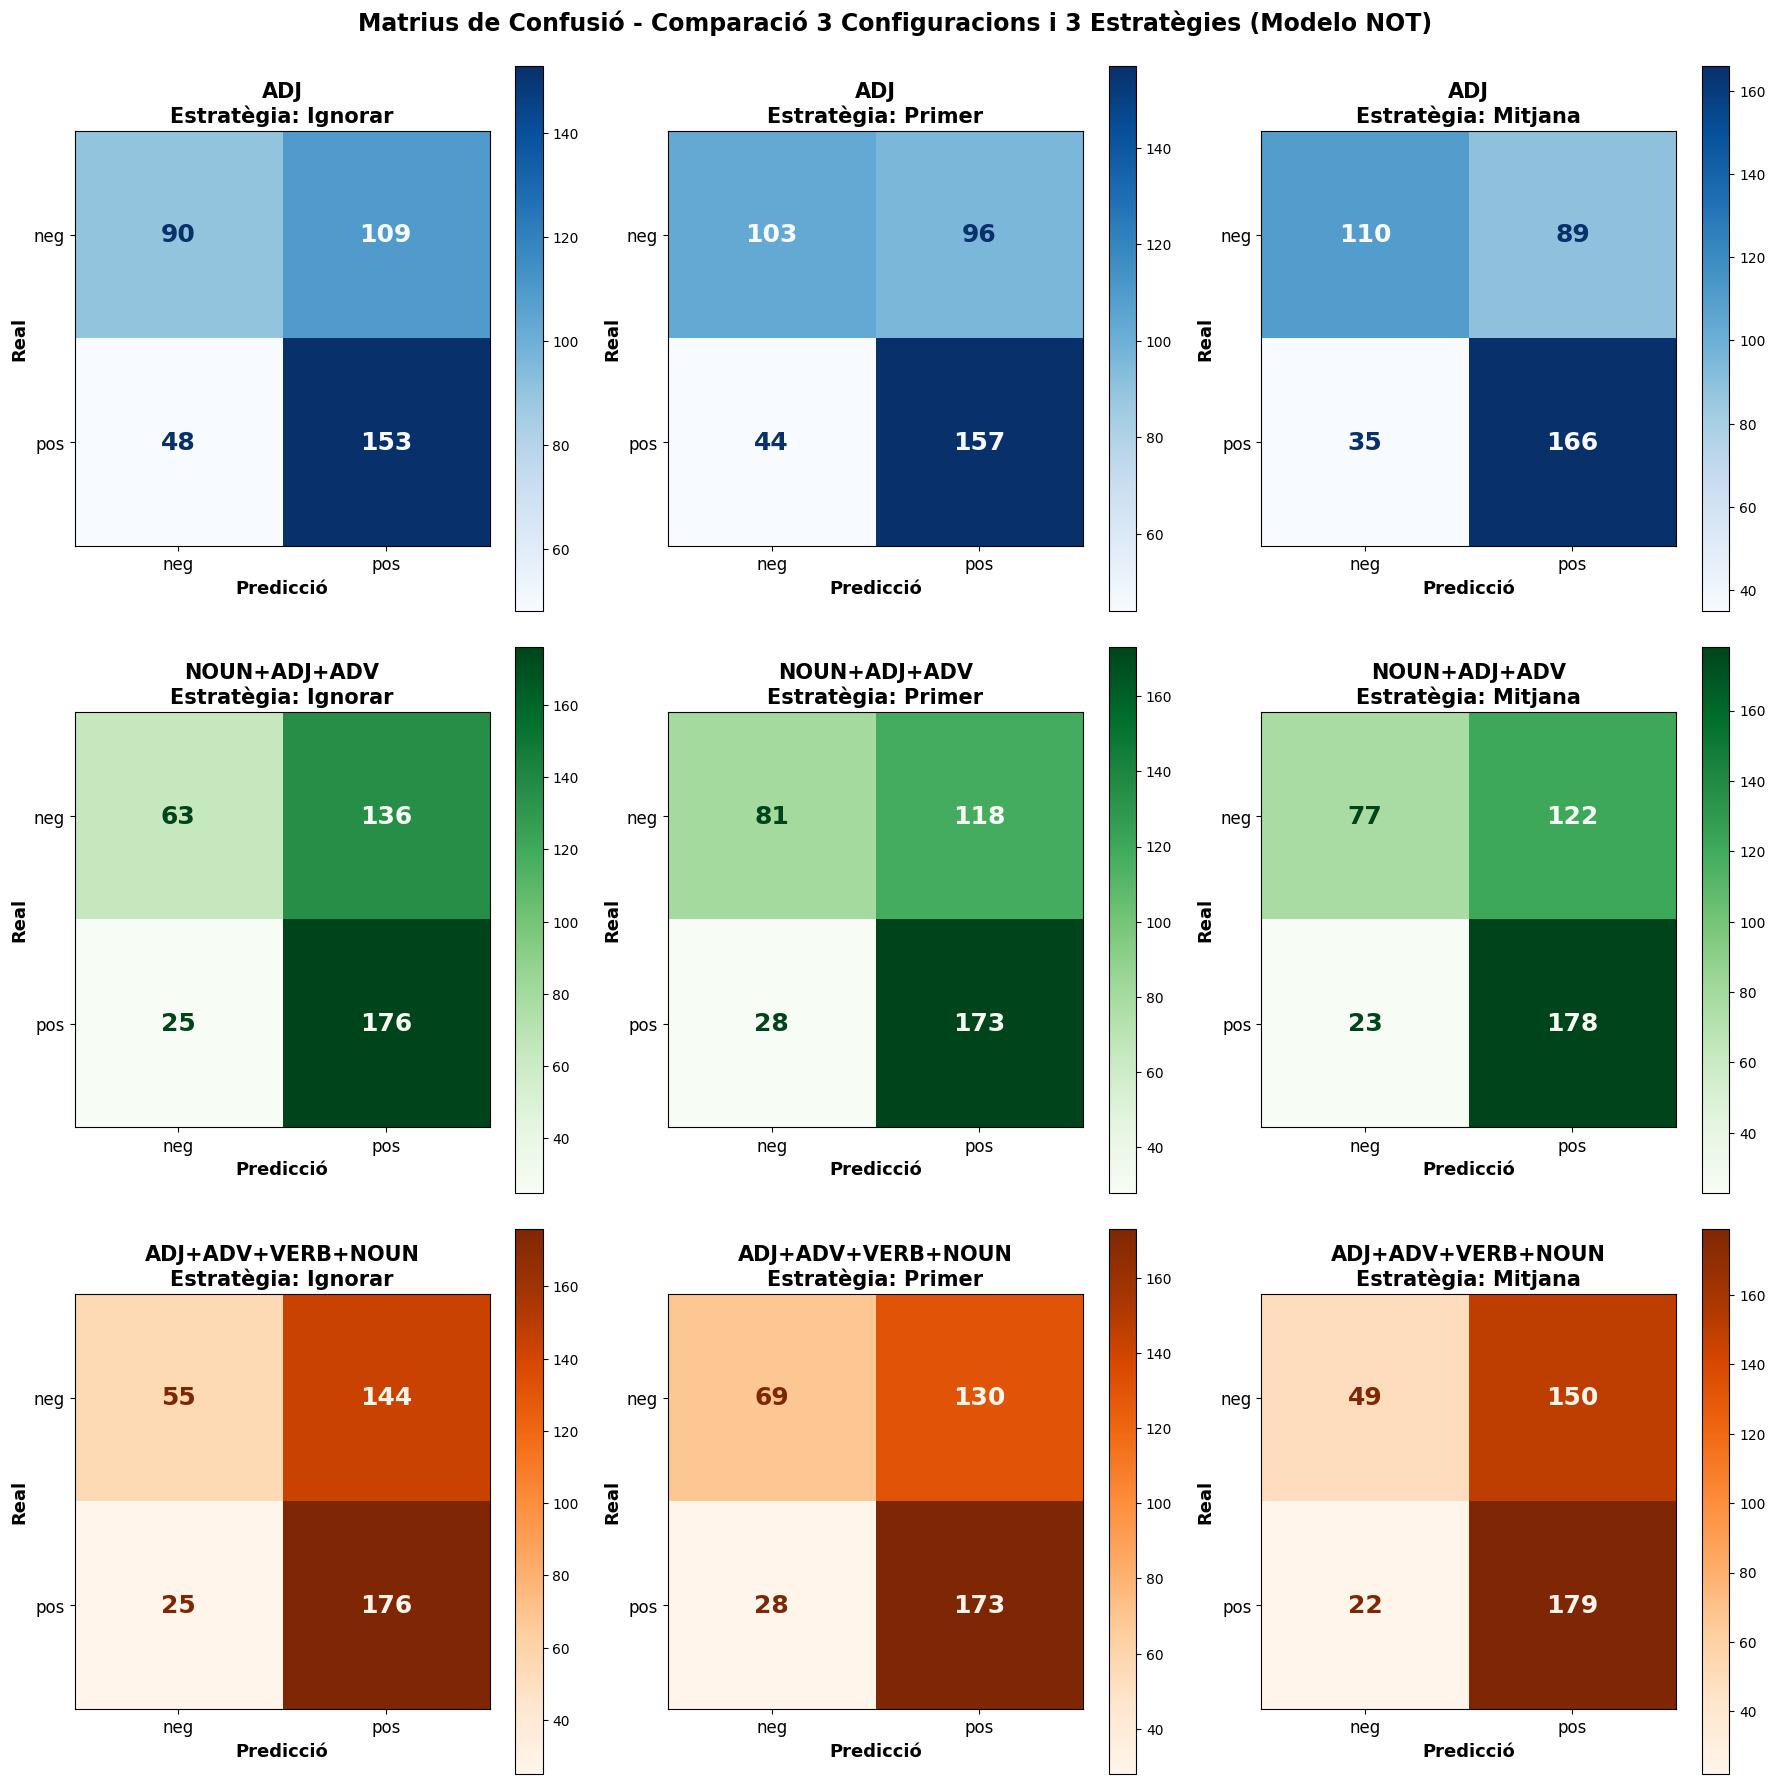

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Gráfico: 9 Matrices de Confusión en formato 3x3 (3 configuraciones × 3 estrategies)
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

configs = list(unsupervised_results_not.keys())
strategies = ["ignore", "first", "average"]
colors_list = ['Blues', 'Greens', 'Oranges']
strategy_names = {"ignore": "Ignorar", "first": "Primer", "average": "Mitjana"}

idx = 0
for config_idx, config_name in enumerate(configs):
    for strat_idx, strategy in enumerate(strategies):
        cm = unsupervised_results_not[config_name][strategy]['cm']
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])
        disp.plot(cmap=colors_list[config_idx], ax=axes[idx], values_format='d')
        
        # Aumentar tamaño de fuente de los números en la matriz
        for text in axes[idx].texts:
            text.set_fontsize(18)
            text.set_weight('bold')
        
        # Títol amb configuració i estratègia
        title = f"{config_name}\nEstratègia: {strategy_names[strategy]}"
        axes[idx].set_title(title, fontsize=15, fontweight='bold')
        
        # Augmentar tamanys dels eixos
        axes[idx].set_xlabel("Predicció", fontsize=13, fontweight='bold')
        axes[idx].set_ylabel("Real", fontsize=13, fontweight='bold')
        axes[idx].tick_params(axis='both', labelsize=12)
        
        idx += 1

plt.suptitle('Matrius de Confusió - Comparació 3 Configuracions i 3 Estratègies (Modelo NOT)', 
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


Les matrius de confusió il·lustren amb claredat el biaix positiu del model. En la configuració *ADJ*, els resultats són molt similars als del model base: amb *average*, 166 veritables positius, 35 falsos positius, 89 falsos negatius i 110 veritables negatius. La introducció de negacions ha tingut un impacte mínim en aquesta configuració, cosa coherent amb el fet que el patró `NOT [ADV]* ADJ` afecta principalment adjectius però és relativament poc freqüent en el corpus.

En canvi, les configuracions *NOUN+ADJ+ADV* i *ADJ+ADV+VERB+NOUN* mostren un deteriorament clar. En *NOUN+ADJ+ADV + ignore*, els veritables negatius cauen fins a 63 (enfront de 153 en el model base), mentre que els falsos positius s'eleven a 25: el model quasi mai prediu negatiu. Amb *average*, la situació millora lleugerament (77 veritables negatius), però el biaix positiu es manté molt pronunciat. La configuració *ADJ+ADV+VERB+NOUN* presenta els pitjors resultats en termes d'equilibri: amb *average*, només 49 veritables negatius i 22 falsos positius, però 150 falsos negatius, cosa que implica que tres quartes parts de les ressenyes negatives no es detecten.

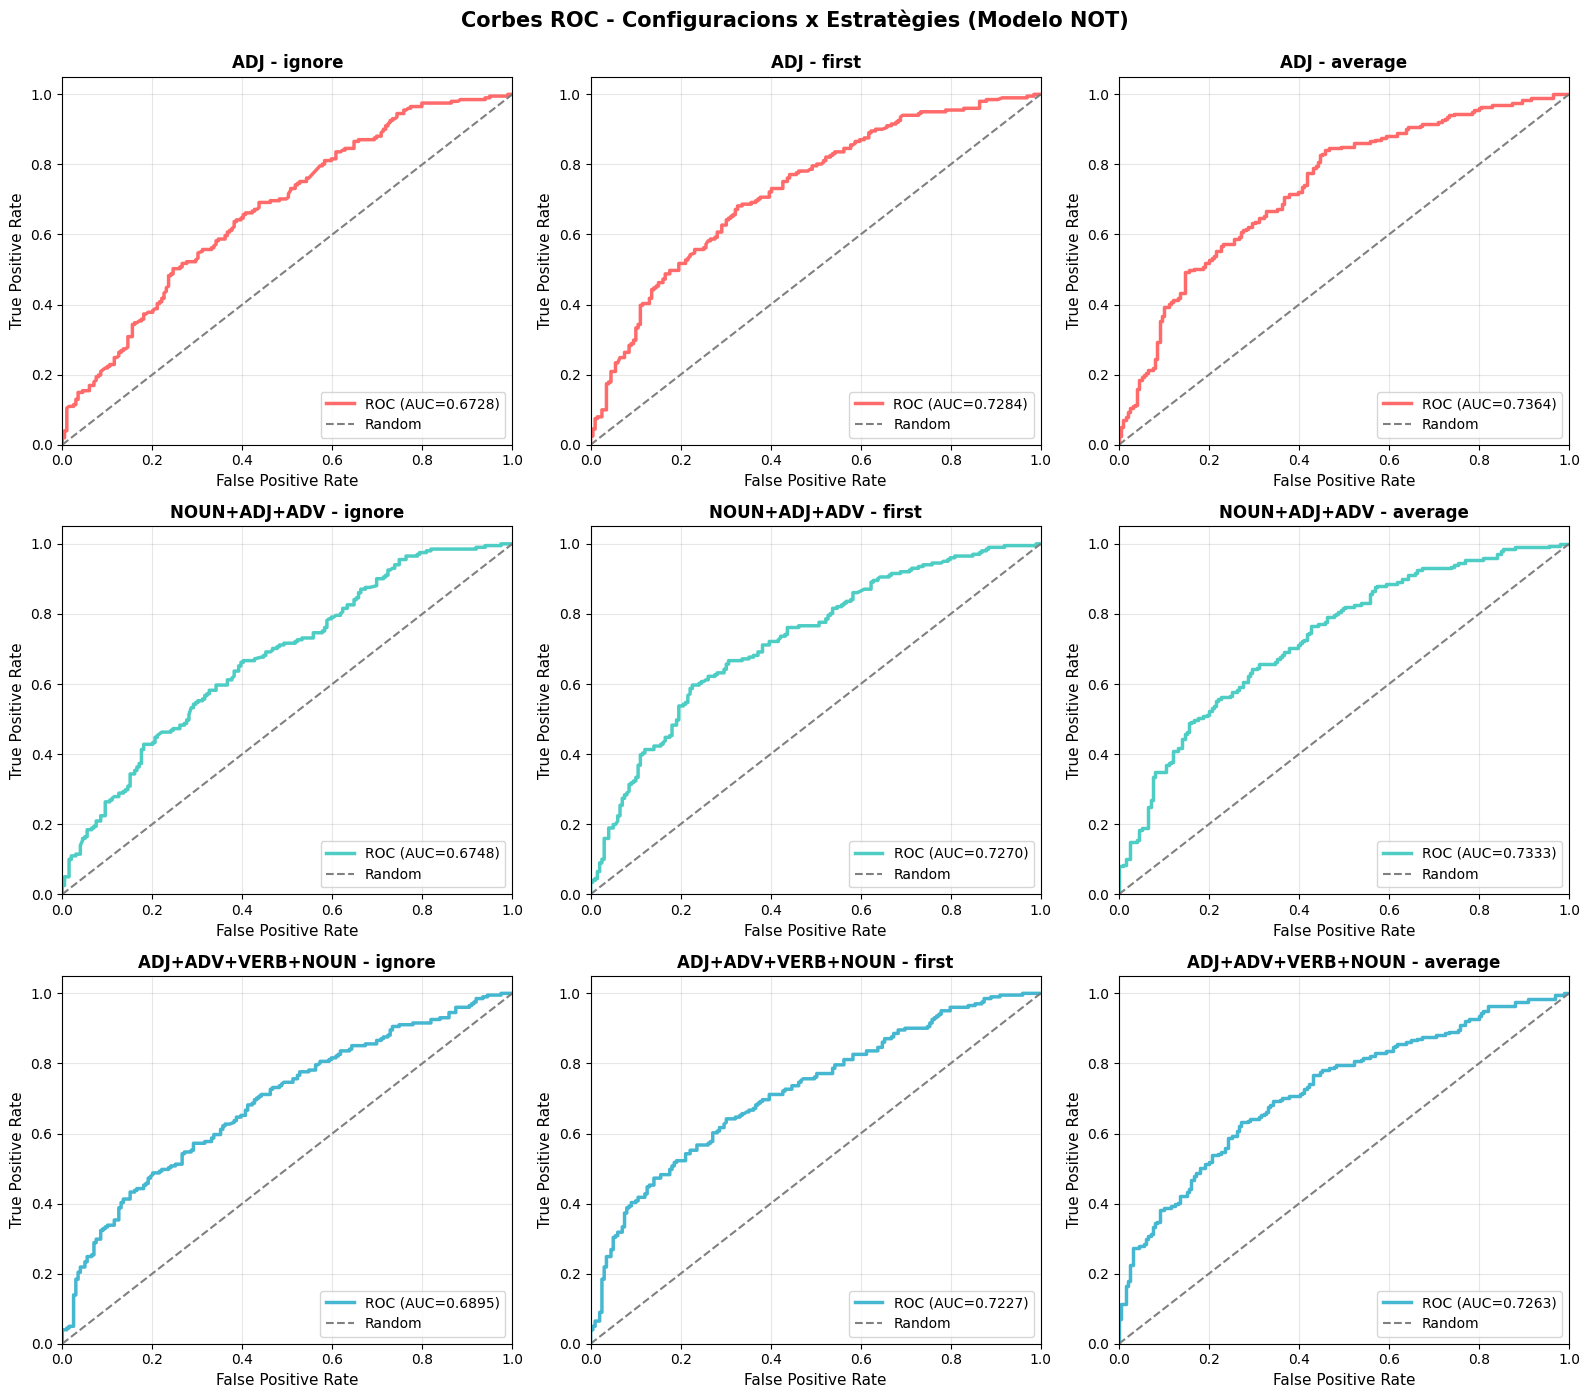

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(unsupervised_results_not), len(strategies), figsize=(16, 14))

configs = list(unsupervised_results_not.keys())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for row, config_name in enumerate(configs):
    for col, strategy in enumerate(strategies):
        result = unsupervised_results_not[config_name][strategy]
        fpr = result['fpr']
        tpr = result['tpr']
        roc_auc = result['roc_auc']
        
        ax = axes[row, col]
        
        ax.plot(fpr, tpr, color=colors[row], lw=2.5, 
                label=f'ROC (AUC={roc_auc:.4f})')
        ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random')
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.set_title(f'{config_name} - {strategy}', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(alpha=0.3)

plt.suptitle('Corbes ROC - Configuracions x Estratègies (Modelo NOT)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


#### Estadístiques de cobertura de synsets

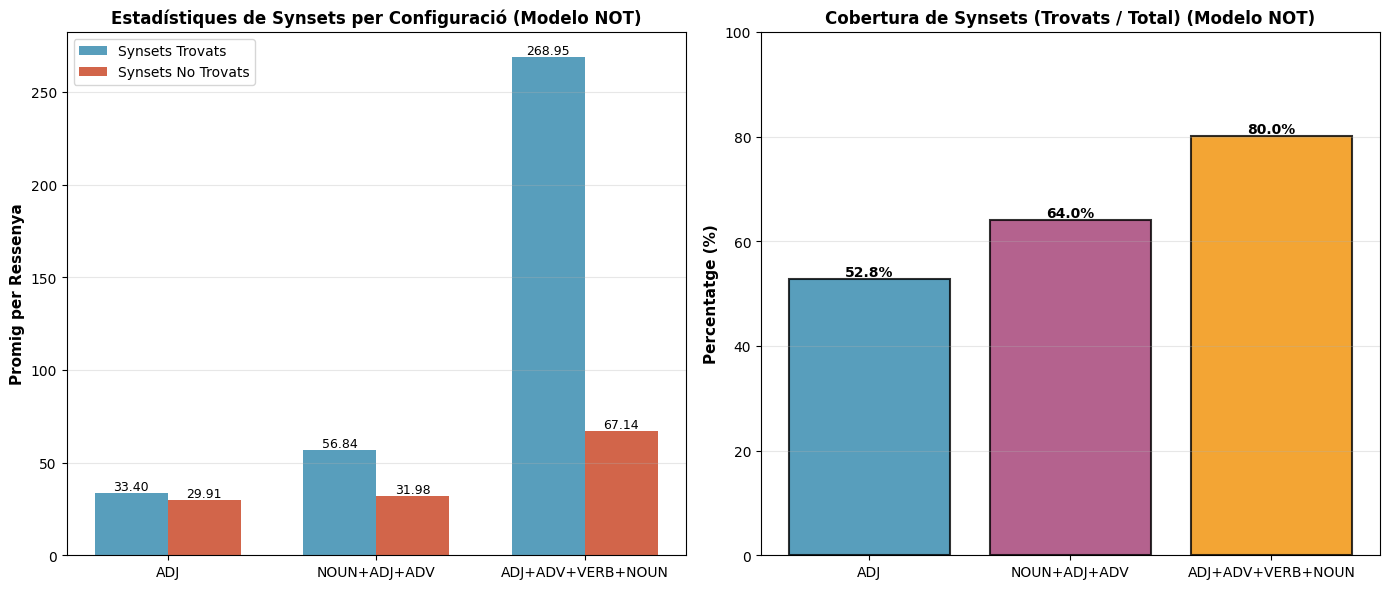


RESUM ESTADÍSTIQUES DE SYNSETS PER CONFIGURACIÓ (MODELO NOT)

     Configuració Synsets Trovats (avg) Synsets No Trovats (avg) Cobertura (%)
              ADJ                 33.40                    29.91         52.8%
     NOUN+ADJ+ADV                 56.84                    31.98         64.0%
ADJ+ADV+VERB+NOUN                268.95                    67.14         80.0%


In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

configs = list(unsupervised_results_not.keys())
avg_found_list = []
avg_not_found_list = []
coverage_pct_list = []

for config_name in configs:
    stats = unsupervised_results_not[config_name]['ignore']['synsets_stats']
    avg_found = np.mean(stats["found"])
    avg_not_found = np.mean(stats["not_found"])
    avg_processed = np.mean(stats["processed"])
    
    # Calcular cobertura (porcentaje de synsets encontrados)
    if avg_processed > 0:
        coverage_pct = (avg_found / avg_processed) * 100
    else:
        coverage_pct = 0
    
    avg_found_list.append(avg_found)
    avg_not_found_list.append(avg_not_found)
    coverage_pct_list.append(coverage_pct)

# Crear gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Synsets trovados vs No encontrados
x = np.arange(len(configs))
width = 0.35

bars1 = axes[0].bar(x - width/2, avg_found_list, width, label='Synsets Trovats', color='#2E86AB', alpha=0.8)
bars2 = axes[0].bar(x + width/2, avg_not_found_list, width, label='Synsets No Trovats', color='#C73E1D', alpha=0.8)

axes[0].set_ylabel('Promig per Ressenya', fontsize=11, fontweight='bold')
axes[0].set_title('Estadístiques de Synsets per Configuració (Modelo NOT)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(configs)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Afegir valors a les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Porcentaje de cobertura (synsets encontrados / total procesados)
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars3 = axes[1].bar(configs, coverage_pct_list, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('Percentatge (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Cobertura de Synsets (Trovats / Total) (Modelo NOT)', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 100])
axes[1].grid(axis='y', alpha=0.3)

# Afegir valors percentuals
for bar in bars3:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Taula resum d'estadístiques
print("\nRESUM ESTADÍSTIQUES DE SYNSETS PER CONFIGURACIÓ (MODELO NOT)")
print("="*80)

summary_data = {
    "Configuració": configs,
    "Synsets Trovats (avg)": [f"{x:.2f}" for x in avg_found_list],
    "Synsets No Trovats (avg)": [f"{x:.2f}" for x in avg_not_found_list],
    "Cobertura (%)": [f"{x:.1f}%" for x in coverage_pct_list]
}

df_stats = pd.DataFrame(summary_data)
print("\n" + df_stats.to_string(index=False))


La cobertura ha millorat respecte a la versió anterior del model amb negacions gràcies a la correcció del càlcul. La configuració *ADJ* manté una cobertura del 52.8% (33 synsets de mitjana), idèntica a la del model base. La configuració *NOUN+ADJ+ADV* passa del 15.8% mal calculat al 64.0% correcte (57 synsets de mitjana), un valor ara comparable, tot i que encara inferior, al 78.6% del model base. La diferència residual s'explica perquè el mecanisme de negació elimina del text els tokens de negació i, en alguns casos, redueix lleugerament el nombre de noms i adverbis disponibles per al càlcul. La configuració *ADJ+ADV+VERB+NOUN* manté una cobertura del 80.0%, pràcticament idèntica al model base.

Malgrat que la cobertura és similar a la del model base, els resultats empitjoren considerablement en *NOUN+ADJ+ADV* i *ADJ+ADV+VERB+NOUN*. Això confirma que el problema no és de cobertura sinó d'efecte de la inversió de signe: quan s'inverteixen adjectius i adverbis en contextos de negació, en molts casos s'estan penalitzant paraules que contribuïen correctament al sentiment global, generant un soroll addicional que desplaça les puntuacions cap al positiu de manera sistemàtica.

#### Millor model i conclusions

El millor model d'aquest apartat és, igual que en el model base, la configuració **ADJ + average**, amb una accuracy de 0.690, un F1-Score de 0.728 i una AUC de 0.736. És l'única configuració on el tractament de negacions no ha introduït degradació, probablement perquè la baixa cobertura dels adjectius fa que el nombre de negacions capturades sigui petit i el seu impacte limitat.

En termes generals, els resultats d'aquest model se situen per sota del model base en la majoria de configuracions, amb accuracy entre 0.570 i 0.690. La conclusió principal és que el mecanisme de negació per patró sintàctic `NOT [ADV]* ADJ`, tot i ser conceptualment més precís que una finestra fixa, no aporta millores pràctiques en aquest corpus i context, i en les configuracions amb més categories gramaticals introdueix un biaix positiu que perjudica significativament la precisió del sistema.


### Anàlisi d'errors


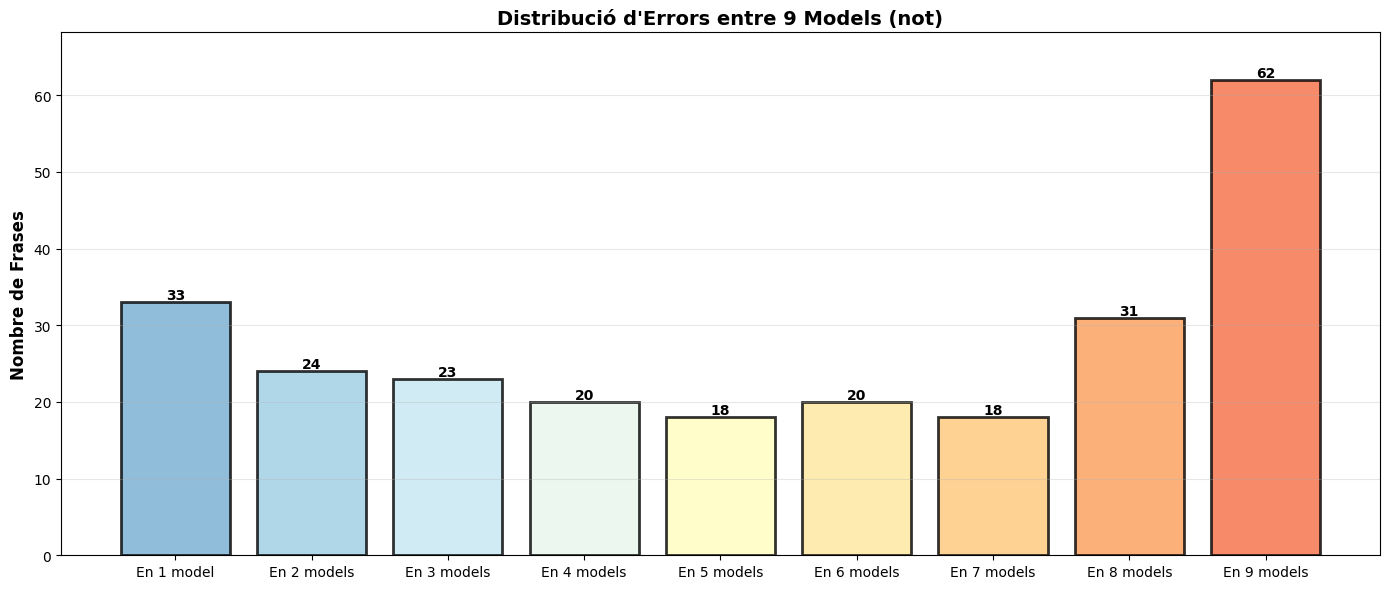

In [42]:
import matplotlib.pyplot as plt
import numpy as np

configs = list(unsupervised_results_not.keys())
total_models = len(configs) * len(strategies)

# Contar para cada frase en cuántos modelos falla
error_count = np.zeros(len(y_test_arr_ns))

for config_name in configs:
    for strategy in strategies:
        errors_mask = np.array(unsupervised_results_not[config_name][strategy]['errors_mask'])
        error_count += errors_mask.astype(int)

# Contar cuántas frases fallan en exactamente n modelos
errors_by_count = {}
for n in range(1, total_models + 1):
    errors_by_count[n] = np.sum(error_count == n)

# Crear gràfic
fig, ax = plt.subplots(figsize=(14, 6))

categories = [f"En {n} model{'s' if n > 1 else ''}" for n in range(1, total_models + 1)]
values = [errors_by_count[n] for n in range(1, total_models + 1)]
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, total_models))

bars = ax.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

ax.set_ylabel('Nombre de Frases', fontsize=12, fontweight='bold')
ax.set_title(f'Distribució d\'Errors entre {total_models} Models (not)', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(values) + max(values)*0.1])
ax.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()



La distribució dels errors per consistència entre models mostra que **62 textos van ser mal classificats per la totalitat dels nou models**, un augment considerable respecte als 39 del model base. La distribució completa és: 33 textos mal classificats per exactament 1 model, 24 per 2, 23 per 3, 20 per 4, 18 per 5, 20 per 6, 18 per 7, 31 per 8, i 62 per tots nou. L'increment dels errors completament sistemàtics indica que el tractament de negacions ha creat un nou nucli dur d'errors que cap configuració és capaç de corregir.


In [43]:
from nltk.corpus import movie_reviews as mr
from sklearn.model_selection import train_test_split

def analizar_error(num_error):
    """
    Mostra la informació completa d'un error específic que falla en els 9 models.
    """
    
    configs = list(unsupervised_results_not.keys())
    
    errors_all_models = None
    for config_name in configs:
        for strategy in strategies:
            errors_mask = np.array(unsupervised_results_not[config_name][strategy]['errors_mask'])
            if errors_all_models is None:
                errors_all_models = errors_mask.copy()
            else:
                errors_all_models = errors_all_models & errors_mask
    
    errors_all_models = np.where(errors_all_models)[0]
    
    if num_error < 1 or num_error > len(errors_all_models):
        print(f"Error: El número ha d'estar entre 1 i {len(errors_all_models)}")
        return
    
    idx = errors_all_models[num_error - 1]
    
    actual = y_test_split[idx]
    text_original = X_test_orig[idx].replace('\n', ' ')
    text_clean = X_test_clean[idx]
    
    print(f"ERROR {num_error} (de {len(errors_all_models)} totals)")
    print(f"\nETIQUETA REAL: {actual.upper()}")
    
    print(f"\nTEXT ORIGINAL:")
    print(f"  {text_original}")
    
    print(f"\nTEXT PREPROCESSAT:")
    print(f"  {text_clean}")
    
    print(f"\nPREDICCIONS (9 MODELS):")
    print("-" * 120)
    
    for config_name in configs:
        print(f"\nConfiguració: {config_name}")
        for strategy in strategies:
            result = unsupervised_results_not[config_name][strategy]
            pred = result['y_pred'][idx]
            score = result['scores'][idx]
            print(f"  • Estratègia '{strategy:8s}' - Predicció: {pred:4s} | Puntuació: {score:7.4f}")

In [44]:
analizar_error(1)
analizar_error(2)
analizar_error(3)
analizar_error(4)
analizar_error(5)
analizar_error(6)
analizar_error(7)

ERROR 1 (de 62 totals)

ETIQUETA REAL: NEG

TEXT ORIGINAL:
   " the 44 caliber killer has struck again . "  starring john leguizamo , mira sorvino , adrian brody , jennifer esposito , michael rispoli , bebe neuwirth .  rated r .  summer of sam will be remembered as a waste of spike lee's abilities .  lee is a great filmmaker , often exhibiting kinetic visual flair on par with brian depalma and martin scorsese and a storytelling ability comparable to steven spielberg .  but here , he gets himself into a bind .  his latest effort is a case of a director pretending he has something to say when in reality there is little of substance to absorb from his work .  the summer of 1977 was an unusual summer in new york city .  it was the hottest summer on record .  to boot , new york's first serial killer was on the loose : calling himself the son of sam , david berkowitz killed 9 people in the new york area and frightened the whole city population .  so it was understandable that when nyc was hi


L'anàlisi dels errors sistemàtics revela un patró gairebé exclusiu: tots els casos del grup de 62 corresponen a ressenyes **negatives classificades com a positives**, amb puntuacions consistentment positives a totes les configuracions. Això confirma que el problema de fons no és la gestió de les negacions, sinó que el vocabulari que apareix en ressenyes negatives de cinema conté adjectius i paraules que SentiWordNet valora com a positius, probablement perquè el crític descriu la pel·lícula amb cert detall abans de condemnar-la, o perquè utilitza estructures retòriques complexes que el sistema no pot interpretar. El primer error il·lustrat és paradigmàtic en aquest sentit: la ressenya de *Summer of Sam* és clarament negativa, però conté expressions com *"great filmmaker"*, *"kinetic visual flair"* o *"riveting performance"* que, tractades aïlladament, generen una puntuació neta positiva que cap de les nou configuracions aconsegueix revertir.

En definitiva, el tractament de negacions per patró sintàctic aporta una major precisió conceptual respecte a la finestra fixa, però els resultats mostren que la limitació principal del sistema no és la gestió de les negacions sinó la incapacitat de capturar l'estructura argumentativa global d'una ressenya, on les paraules positives i negatives coexisteixen en proporcions que un simple agregat lèxic no pot interpretar correctament.

## Ajust del llindar de decisió (*fine-tuning*)

### Motivació i protocol

En els models no supervisats presentats fins ara, el llindar de decisió per classificar una ressenya com a positiva o negativa s'ha fixat a 0: qualsevol puntuació positiva es prediu com a *pos* i qualsevol puntuació negativa o zero com a *neg*. Aquest llindar és arbitrari i no té per què ser òptim per al corpus concret que s'està analitzant. Per exemple, si les puntuacions del model tendeixen a ser lleugerament positives de manera sistemàtica (a causa del biaix positiu de SentiWordNet o del vocabulari cinematogràfic) un llindar lleugerament superior a 0 podria millorar la classificació.

L'ajust del llindar és l'única forma de *fine-tuning* aplicable a un sistema no supervisat pur com el nostre, ja que no hi ha paràmetres de model que es puguin optimitzar. El procés consisteix a cercar el llindar que maximitza una mètrica sobre un conjunt de dades conegut, i aplicar-lo després sobre el test.

Pel que fa al protocol, s'ha optat per cercar el llindar òptim directament sobre el conjunt de **train** (`X_train_ns` i `X_train_not` respectivament), sense crear un conjunt de validació addicional. Aquesta decisió es justifica per dues raons: en primer lloc, com que el model no ha après res del train (no hi ha pesos ni paràmetres entrenats) no existeix el risc de *data leakage* en el sentit clàssic; en segon lloc, disposar de 1.600 mostres per calibrar el llindar és més robust que usar un subconjunt de validació de ~320 mostres. El llindar trobat sobre train s'aplica directament sobre `X_test_ns` i `X_test_not` per a l'avaluació final, que és el mateix conjunt de test usat en tots els experiments anteriors.


El criteri d'optimització és l'**índex de Youden** (`TPR - FPR`), que identifica el punt de la corba ROC més proper a (FPR=0, TPR=1) i és equivalent a buscar el millor balanç entre sensibilitat i especificitat. La motivació d'usar aquest criteri en lloc de maximitzar directament el F1 o l'accuracy és que l'índex de Youden penalitza igualment els falsos positius i els falsos negatius, cosa que és coherent amb una tasca de classificació binària equilibrada com la present, on cap de les dues classes té un cost d'error superior a l'altra. En altres paraules, el llindar de Youden és el que maximitza la capacitat del model de distingir entre les dues classes de manera simultània, sense afavorir cap d'elles. S'ha aplicat sobre la configuració òptima identificada en els apartats anteriors: **ADJ + average**, tant per al model base com per al model amb negacions.


In [55]:
def find_best_threshold(scores, y_true, metric="accuracy"):
    """
    Cerca el llindar òptim que maximitza la mètrica escollida.
    Retorna el millor llindar i la millor puntuació.
    """
    thresholds = np.linspace(scores.min(), scores.max(), 200)
    best_threshold = 0.0
    best_score = -1.0

    for threshold in thresholds:
        y_pred = np.where(scores > threshold, "pos", "neg")

        if metric == "f1":
            score = f1_score(y_true, y_pred, pos_label="pos", zero_division=0)
        elif metric == "accuracy":
            score = accuracy_score(y_true, y_pred)

        if score > best_score:
            best_score = score
            best_threshold = threshold

    return best_threshold, best_score



def find_best_threshold_auc(scores, y_true):
    """
    Troba el llindar òptim a partir de la corba ROC.
    Maximitza el punt més proper a (FPR=0, TPR=1), 
    equivalent a maximitzar TPR - FPR (índex de Youden).
    """
    y_true_bin = (np.array(y_true) == "pos").astype(int)
    scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)
    
    fpr, tpr, thresholds_roc = roc_curve(y_true_bin, scores_norm)
    roc_auc = auc(fpr, tpr)
    
    # Índex de Youden: maximitza TPR - FPR
    youden_idx = np.argmax(tpr - fpr)
    best_threshold_norm = thresholds_roc[youden_idx]
    
    # Convertir el llindar normalitzat de tornada a l'escala original
    best_threshold = best_threshold_norm * (scores.max() - scores.min() + 1e-10) + scores.min()
    
    return best_threshold, roc_auc, fpr, tpr

In [57]:
BEST_POS = ["ADJ"]
BEST_STRATEGY = "average"

print("=" * 60)
print("MODEL BASE — cerca del llindar òptim")
print("=" * 60)

# 1. Scores sobre train -> trobar llindar
train_scores_base = []
for text in X_train_ns:
    score, _, _ = sentiment_score_unsupervised_wsd(
        text, pos_categories=BEST_POS, strategy=BEST_STRATEGY
    )
    train_scores_base.append(score)
train_scores_base = np.array(train_scores_base)

best_thr_base, auc_base, _, _ = find_best_threshold_auc(train_scores_base, y_train_ns)
print(f"  Millor llindar (train): {best_thr_base:.4f} | AUC train: {auc_base:.4f}")

# 2. Scores sobre test -> avaluar
test_scores_base = []
for text in X_test_ns:
    score, _, _ = sentiment_score_unsupervised_wsd(
        text, pos_categories=BEST_POS, strategy=BEST_STRATEGY
    )
    test_scores_base.append(score)
test_scores_base = np.array(test_scores_base)

y_pred_base_tuned = np.where(test_scores_base > best_thr_base, "pos", "neg")

acc_base_tuned  = accuracy_score(y_test_ns, y_pred_base_tuned)
prec_base_tuned = precision_score(y_test_ns, y_pred_base_tuned, pos_label="pos", zero_division=0)
rec_base_tuned  = recall_score(y_test_ns, y_pred_base_tuned, pos_label="pos", zero_division=0)
f1_base_tuned   = f1_score(y_test_ns, y_pred_base_tuned, pos_label="pos", zero_division=0)
cm_base_tuned   = confusion_matrix(y_test_ns, y_pred_base_tuned)

y_test_bin = (np.array(y_test_ns) == "pos").astype(int)
test_scores_norm = (test_scores_base - test_scores_base.min()) / (test_scores_base.max() - test_scores_base.min() + 1e-10)
fpr_test, tpr_test, _ = roc_curve(y_test_bin, test_scores_norm)
auc_test_base = auc(fpr_test, tpr_test)

print(f"\n  RESULTATS TEST (llindar = {best_thr_base:.4f})")
print(f"  Accuracy:  {acc_base_tuned:.4f}")
print(f"  Precisió:  {prec_base_tuned:.4f}")
print(f"  Recall:    {rec_base_tuned:.4f}")
print(f"  F1-Score:  {f1_base_tuned:.4f}")
print(f"  AUC:       {auc_test_base:.4f}")
print(f"  Matriu de confusió:\n{cm_base_tuned}")

MODEL BASE — cerca del llindar òptim
  Millor llindar (train): 0.0237 | AUC train: 0.7277

  RESULTATS TEST (llindar = 0.0237)
  Accuracy:  0.6800
  Precisió:  0.6952
  Recall:    0.6468
  F1-Score:  0.6701
  AUC:       0.7498
  Matriu de confusió:
[[142  57]
 [ 71 130]]


In [ ]:
print("=" * 60)
print("MODEL AMB CONTROL DE NEGACIONS — cerca del llindar òptim")
print("=" * 60)

# 1. Scores sobre train -> trobar llindar
train_scores_not = []
for text in X_train_not:
    score, _, _ = sentiment_score_unsupervised_wsd_not(
        text, pos_categories=BEST_POS, strategy=BEST_STRATEGY
    )
    train_scores_not.append(score)
train_scores_not = np.array(train_scores_not)

best_thr_not, auc_not, _, _ = find_best_threshold_auc(train_scores_not, y_train_not)
print(f"  Millor llindar (train): {best_thr_not:.4f} | AUC train: {auc_not:.4f}")

# 2. Scores sobre test -> avaluar
test_scores_not = []
for text in X_test_not:
    score, _, _ = sentiment_score_unsupervised_wsd_not(
        text, pos_categories=BEST_POS, strategy=BEST_STRATEGY
    )
    test_scores_not.append(score)
test_scores_not = np.array(test_scores_not)

y_pred_not_tuned = np.where(test_scores_not > best_thr_not, "pos", "neg")

acc_not_tuned  = accuracy_score(y_test_not, y_pred_not_tuned)
prec_not_tuned = precision_score(y_test_not, y_pred_not_tuned, pos_label="pos", zero_division=0)
rec_not_tuned  = recall_score(y_test_not, y_pred_not_tuned, pos_label="pos", zero_division=0)
f1_not_tuned   = f1_score(y_test_not, y_pred_not_tuned, pos_label="pos", zero_division=0)
cm_not_tuned   = confusion_matrix(y_test_not, y_pred_not_tuned)

y_test_not_bin = (np.array(y_test_not) == "pos").astype(int)
test_scores_not_norm = (test_scores_not - test_scores_not.min()) / (test_scores_not.max() - test_scores_not.min() + 1e-10)
fpr_test_not, tpr_test_not, _ = roc_curve(y_test_not_bin, test_scores_not_norm)
auc_test_not = auc(fpr_test_not, tpr_test_not)

print(f"\n  RESULTATS TEST (llindar = {best_thr_not:.4f})")
print(f"  Accuracy:  {acc_not_tuned:.4f}")
print(f"  Precisió:  {prec_not_tuned:.4f}")
print(f"  Recall:    {rec_not_tuned:.4f}")
print(f"  F1-Score:  {f1_not_tuned:.4f}")
print(f"  AUC:       {auc_test_not:.4f}")
print(f"  Matriu de confusió:\n{cm_not_tuned}")

# COMPARACIÓ FINAL
print("\n" + "=" * 60)
print("COMPARACIÓ: llindar 0.0 vs. llindar ajustat")
print("=" * 60)
print(f"\n{'Model':<35} {'Llindar':>10} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
print("-" * 75)
print(f"{'Base (llindar=0.0)':<35} {'0.0000':>10} {'0.6900':>10} {'0.7281':>10} {'0.7498':>10}")
print(f"{'Base (llindar ajustat)':<35} {best_thr_base:>10.4f} {acc_base_tuned:>10.4f} {f1_base_tuned:>10.4f} {auc_test_base:>10.4f}")
print(f"{'NOT (llindar=0.0)':<35} {'0.0000':>10} {'0.6900':>10} {'0.7281':>10} {'0.7364':>10}")
print(f"{'NOT (llindar ajustat)':<35} {best_thr_not:>10.4f} {acc_not_tuned:>10.4f} {f1_not_tuned:>10.4f} {auc_test_not:>10.4f}")

MODEL AMB CONTROL DE NEGACIONS — cerca del llindar òptim
  Millor llindar (train): 0.0178 | AUC train: 0.7254

  RESULTATS TEST (llindar = 0.0178)
  Accuracy:  0.6650
  Precisió:  0.6667
  Recall:    0.6667
  F1-Score:  0.6667
  AUC:       0.7364
  Matriu de confusió:
[[132  67]
 [ 67 134]]

COMPARACIÓ: llindar 0.0 vs. llindar ajustat

Model                                  Llindar   Accuracy         F1        AUC
---------------------------------------------------------------------------
Base (llindar=0.0)                      0.0000     0.6900     0.7281     0.7498
Base (llindar ajustat)                  0.0237     0.6800     0.6701     0.7498
NOT (llindar=0.0)                       0.0000     0.6900     0.7281     0.7364
NOT (llindar ajustat)                   0.0178     0.6650     0.6667     0.7364




### Resultats


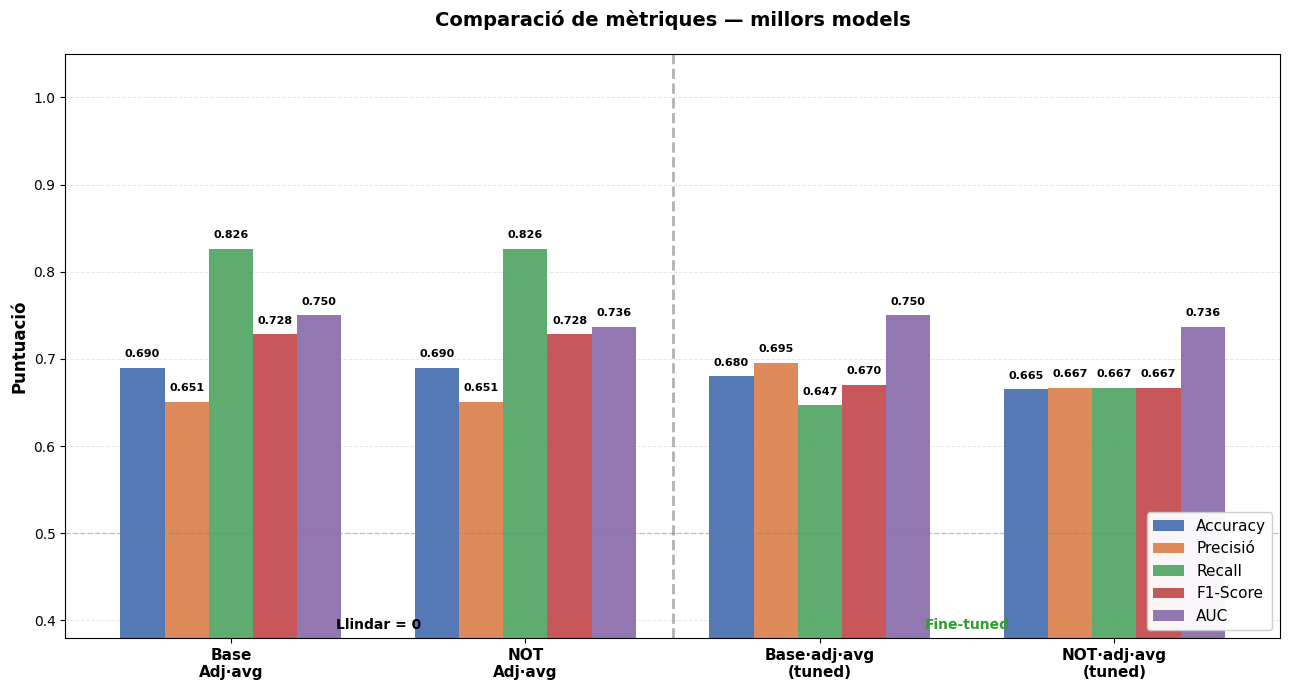

In [72]:
# GRÀFIC 1: MÈTRIQUES COMPARATIVES 

configs_plot    = ["ADJ"]
strategies_plot = ["average"]

labels, acc_vals, prec_vals, rec_vals, f1_vals_, auc_vals_ = [], [], [], [], [], []

# Model base
for config in configs_plot:
    for strategy in strategies_plot:
        r = unsupervised_results[config][strategy]
        labels.append("Base\nAdj·avg")
        acc_vals.append(r["accuracy"])
        prec_vals.append(r["precision"])
        rec_vals.append(r["recall"])
        f1_vals_.append(r["f1"])
        auc_vals_.append(r["roc_auc"])

# Model NOT
for config in configs_plot:
    for strategy in strategies_plot:
        r = unsupervised_results_not[config][strategy]
        labels.append("NOT\nAdj·avg")
        acc_vals.append(r["accuracy"])
        prec_vals.append(r["precision"])
        rec_vals.append(r["recall"])
        f1_vals_.append(r["f1"])
        auc_vals_.append(r["roc_auc"])

# Fine-tuned
labels.append("Base·adj·avg\n(tuned)")
acc_vals.append(acc_base_tuned)
prec_vals.append(prec_base_tuned)
rec_vals.append(rec_base_tuned)
f1_vals_.append(f1_base_tuned)
auc_vals_.append(auc_test_base)

labels.append("NOT·adj·avg\n(tuned)")
acc_vals.append(acc_not_tuned)
prec_vals.append(prec_not_tuned)
rec_vals.append(rec_not_tuned)
f1_vals_.append(f1_not_tuned)
auc_vals_.append(auc_test_not)

# COLORS PER A CADA MÈTRICA
color_acc  = "#4C72B0"  # Blau
color_prec = "#DD8452"  # Taronja
color_rec  = "#55A868"  # Verd
color_f1   = "#C44E52"  # Vermell
color_auc  = "#8C70AC"  # Porpra

x     = np.arange(len(labels))
width = 0.15

fig, ax = plt.subplots(figsize=(13, 7))

bars1 = ax.bar(x - 2*width, acc_vals,  width, label="Accuracy",  color=color_acc,  alpha=0.95)
bars2 = ax.bar(x -   width, prec_vals, width, label="Precisió",  color=color_prec, alpha=0.95)
bars3 = ax.bar(x,           rec_vals,  width, label="Recall",    color=color_rec,  alpha=0.95)
bars4 = ax.bar(x +   width, f1_vals_,  width, label="F1-Score",  color=color_f1,   alpha=0.95)
bars5 = ax.bar(x + 2*width, auc_vals_, width, label="AUC",       color=color_auc,  alpha=0.95)

# FUNCIÓ PER AFEGIR VALORS A SOBRE DE LES BARRES
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)
add_value_labels(bars4)
add_value_labels(bars5)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylim(0.38, 1.05)
ax.set_ylabel("Puntuació", fontsize=12, fontweight='bold')
ax.set_title("Comparació de mètriques — millors models", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="lower right", fontsize=11, framealpha=0.95)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, linewidth=1)
ax.axvline(x=1.5, color="black", linestyle="--", alpha=0.3, linewidth=2)
ax.text(0.5,  0.39, "Llindar = 0",    ha="center", fontsize=10, color="black", fontweight='bold')
ax.text(2.5,  0.39, "Fine-tuned",     ha="center", fontsize=10, color="#2ca02c", fontweight="bold")

ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("metriques_millors_models.png", dpi=150, bbox_inches="tight")
plt.show()

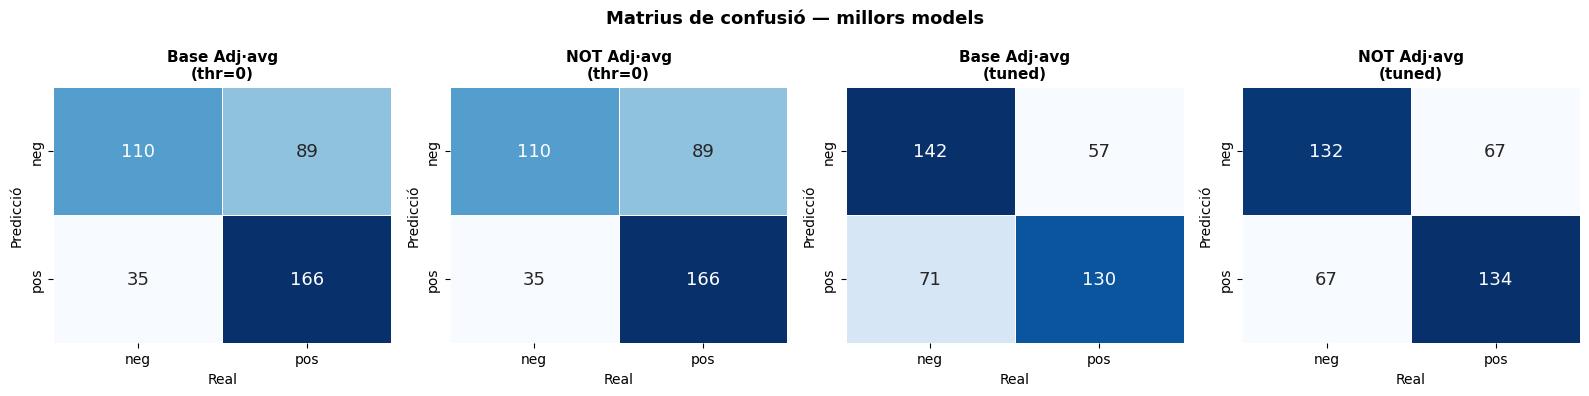

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# GRÀFIC 2: MATRIUS DE CONFUSIÓ 

all_cms = [
    ("Base Adj·avg\n(thr=0)",   unsupervised_results["ADJ"]["average"]["cm"]),
    ("NOT Adj·avg\n(thr=0)",    unsupervised_results_not["ADJ"]["average"]["cm"]),
    ("Base Adj·avg\n(tuned)",   cm_base_tuned),
    ("NOT Adj·avg\n(tuned)",    cm_not_tuned),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (title, cm) in zip(axes, all_cms):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["neg", "pos"],
        yticklabels=["neg", "pos"],
        ax=ax,
        cbar=False,
        linewidths=0.5,
        annot_kws={"size": 13}
    )
    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    ax.set_xlabel("Real",      fontsize=10)
    ax.set_ylabel("Predicció", fontsize=10)

fig.suptitle("Matrius de confusió — millors models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("matrius_millors_models.png", dpi=150, bbox_inches="tight")
plt.show()


El primer que s'observa és que l'AUC no canvia amb l'ajust del llindar, cosa que és esperada: l'AUC és una mètrica independent del llindar que mesura la capacitat discriminativa global del model, i per tant no es veu afectada per on es fixa el tall. Això confirma que els dos models mantenen la seva capacitat de separació de classes independentment del llindar escollit.

Pel que fa a la resta de mètriques, l'ajust del llindar produeix en ambdós casos una **redistribució dels errors**: el llindar òptim trobat (0.0237 per al model base i 0.0178 per al NOT) és lleugerament superior a zero, cosa coherent amb el biaix positiu sistemàtic observat en els models. En pujar el llindar, el model prediu menys positius, cosa que augmenta la precisió i redueix el recall respecte al llindar 0. Les matrius de confusió ho il·lustren clarament: amb el llindar ajustat, el model base passa de 35 falsos positius a 57, però els falsos negatius baixen de 89 a 71; i el model NOT assoleix una distribució perfectament simètrica dels errors (67 falsos positius i 67 falsos negatius), cosa que explica la igualtat exacta entre precisió, recall i F1 (0.6667).

No obstant això, en termes d'accuracy i F1-Score, l'ajust del llindar **no millora els resultats** respecte al llindar 0: el model base passa d'un F1 de 0.728 a 0.670, i el model NOT de 0.728 a 0.667. Això indica que, en aquest corpus, el llindar 0 era de fet una bona elecció per maximitzar el F1, i que el llindar de Youden optimitza un criteri diferent (balanç TPR/FPR) que no coincideix necessàriament amb el millor F1.


### Conclusions

L'ajust del llindar de decisió és una tècnica vàlida de *fine-tuning* per a sistemes no supervisats, però en aquest cas no ha aportat millores en les mètriques principals. El resultat és en si mateix informatiu: el llindar 0 ja estava ben calibrat per maximitzar el F1 en la configuració *ADJ + average*, i desplaçar-lo cap a valors positius únicament redistribueix els errors sense reduir-ne el total. L'única millora observable és un augment de la precisió a costa del recall, que podria ser desitjable en contexts on els falsos positius tinguin un cost alt, però no en una tasca de classificació binària equilibrada com la present.

En definitiva, el millor model del sistema no supervisat continua sent **Base ADJ + average amb llindar 0**, amb una accuracy de 0.690, un F1 de 0.728 i una AUC de 0.750.

## Conclusions del model no supervisat

Els dos models no supervisats implementats (el model base i el model amb tractament de negacions) comparteixen el mateix millor punt de rendiment sense ajust de llindar: la configuració **ADJ + average**, amb una accuracy de 0.690 i un F1-Score de 0.728. El fet que ambdós models convergeixin en la mateixa configuració òptima és en si mateix una conclusió rellevant: els adjectius són les unitats lèxiques més informatives per al sentiment en aquest corpus, i la mitjana de synsets és l'estratègia de desambiguació més robusta quan no es disposa d'un desambiguador de qualitat.

Comparant directament els dos millors models amb llindar 0, el model base és lleugerament superior: obté una AUC de 0.750 enfront del 0.736 del model amb negacions, i en la resta de mètriques els valors són pràcticament idèntics. El tractament de negacions no aporta cap millora i, fora de la configuració *ADJ*, degrada el rendiment de manera notable. Això indica que les negacions no eren la causa principal dels errors del model base, i que el mecanisme implementat, tot i ser sintàcticament més precís que una finestra fixa, introdueix soroll addicional quan s'aplica a categories gramaticals més àmplies.

Pel que fa a l'ajust del llindar de decisió, els resultats mostren que desplaçar el llindar per sobre de zero redistribueix els errors però no en redueix el total: el F1 baixa de 0.728 a 0.670 en el model base i de 0.728 a 0.667 en el model amb negacions. L'única millora observable és un augment de la precisió a costa del recall, cosa que podria ser útil en contexts on els falsos positius tinguessin un cost elevat, però que no és el cas en una tasca de classificació binària equilibrada com la present. En conseqüència, el llindar 0 resulta ser de fet l'opció més adequada per a aquest problema concret.

Cal matisar, però, que aquest resultat no és una llei general: en un altre corpus o amb un model que produís scores més separats i distribuïts, l'ajust de llindar podria perfectament millorar els resultats de manera significativa. En el nostre cas, la majoria de puntuacions es concentren en un rang molt estret al voltant de zero, cosa que fa que petites variacions en el llindar tinguin un impacte desproporcionat i que el llindar trobat sobre el train no generalitzi bé al test. A més, el criteri d'optimització escollit (l'índex de Youden) maximitza el balanç entre TPR i FPR, que no coincideix necessàriament amb el millor F1 o accuracy. Si s'hagués optimitzat el llindar directament sobre el F1 del train, els resultats al test podrien haver estat diferents, tot i que no hi ha garantia que haguessin millorat.

La limitació fonamental d'ambdós models és estructural: un sistema basat en l'agregació de puntuacions lèxiques individuals no pot capturar l'estructura argumentativa d'una ressenya cinematogràfica. Els crítics sovint descriuen els mèrits d'una pel·lícula abans de condemnar-la, utilitzen ironia, o construeixen arguments on les paraules positives i negatives coexisteixen en proporcions que no reflecteixen el sentiment global. Aquesta limitació es manifesta de manera consistent en els errors sistemàtics d'ambdós models, on les ressenyes negatives amb vocabulari superficialment positiu constitueixen el nucli dur d'errors que cap configuració aconsegueix resoldre.

Tenint en compte tots els experiments realitzats, el **millor model del sistema no supervisat és el model base ADJ + average amb llindar 0**, amb una accuracy de 0.690, un F1-Score de 0.728 i una AUC de 0.750. Aquesta configuració ofereix el millor equilibri global entre totes les mètriques avaluades, és la més simple en termes de categories gramaticals processades, i és la més robusta davant de variacions de configuració. El model amb negacions i l'ajust de llindar, tot i ser extensions conceptualment motivades, no aporten millores pràctiques en aquest corpus i afegeixen complexitat sense benefici mesurable.

En termes absoluts, assolir un 69% d'accuracy sense cap exemple d'entrenament és un resultat raonable que posa de manifest la utilitat dels recursos lèxics com SentiWordNet com a línia de base. No obstant això, la comparació amb els models supervisats de la pràctica anterior permetrà quantificar amb precisió el cost d'eliminar la supervisió i determinar fins a quin punt l'aprenentatge automàtic compensa la necessitat de dades etiquetades.

## Comparació entre el sistema supervisat i el sistema no supervisat

### Anàlisi dels resultats


In [75]:
# Model supervisat (XGBoost Bigrames)
y_pred_sup   = y_pred_bigram
acc_sup      = accuracy_score(y_test, y_pred_sup)
prec_sup     = precision_score(y_test, y_pred_sup, pos_label="pos", zero_division=0)
rec_sup      = recall_score(y_test, y_pred_sup, pos_label="pos", zero_division=0)
f1_sup       = f1_score(y_test, y_pred_sup, pos_label="pos", zero_division=0)
cm_sup       = confusion_matrix(y_test, y_pred_sup)

# Model no supervisat (Base ADJ + average, llindar 0)
y_pred_ns    = unsupervised_results["ADJ"]["average"]["y_pred"]
acc_ns       = unsupervised_results["ADJ"]["average"]["accuracy"]
prec_ns      = unsupervised_results["ADJ"]["average"]["precision"]
rec_ns       = unsupervised_results["ADJ"]["average"]["recall"]
f1_ns        = unsupervised_results["ADJ"]["average"]["f1"]
cm_ns        = unsupervised_results["ADJ"]["average"]["cm"]
auc_ns       = unsupervised_results["ADJ"]["average"]["roc_auc"]

# AUC supervisat
y_test_bin   = (np.array(y_test) == "pos").astype(int)
proba_sup    = xgb_bigram.predict_proba(X_test)[:, 1]
fpr_sup, tpr_sup, _ = roc_curve(y_test_bin, proba_sup)
auc_sup      = auc(fpr_sup, tpr_sup)

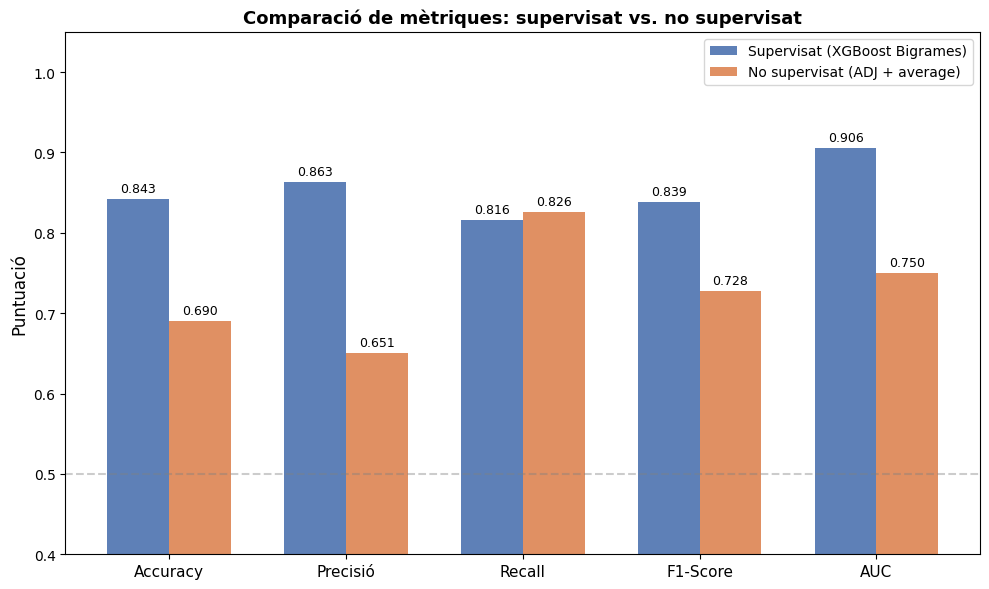

In [76]:
# GRÀFIC 1: COMPARACIÓ DE MÈTRIQUES 

metriques    = ["Accuracy", "Precisió", "Recall", "F1-Score", "AUC"]
vals_sup     = [acc_sup,  prec_sup,  rec_sup,  f1_sup,  auc_sup]
vals_ns      = [acc_ns,   prec_ns,   rec_ns,   f1_ns,   auc_ns]

x     = np.arange(len(metriques))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_sup = ax.bar(x - width/2, vals_sup, width, label="Supervisat (XGBoost Bigrames)",
                  color="#4C72B0", alpha=0.90)
bars_ns  = ax.bar(x + width/2, vals_ns,  width, label="No supervisat (ADJ + average)",
                  color="#DD8452", alpha=0.90)

# Etiquetes de valor sobre cada barra
for bar in bars_sup:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars_ns:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metriques, fontsize=11)
ax.set_ylim(0.4, 1.05)
ax.set_ylabel("Puntuació", fontsize=12)
ax.set_title("Comparació de mètriques: supervisat vs. no supervisat", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("comparacio_metriques_sup_vs_ns.png", dpi=150, bbox_inches="tight")
plt.show()

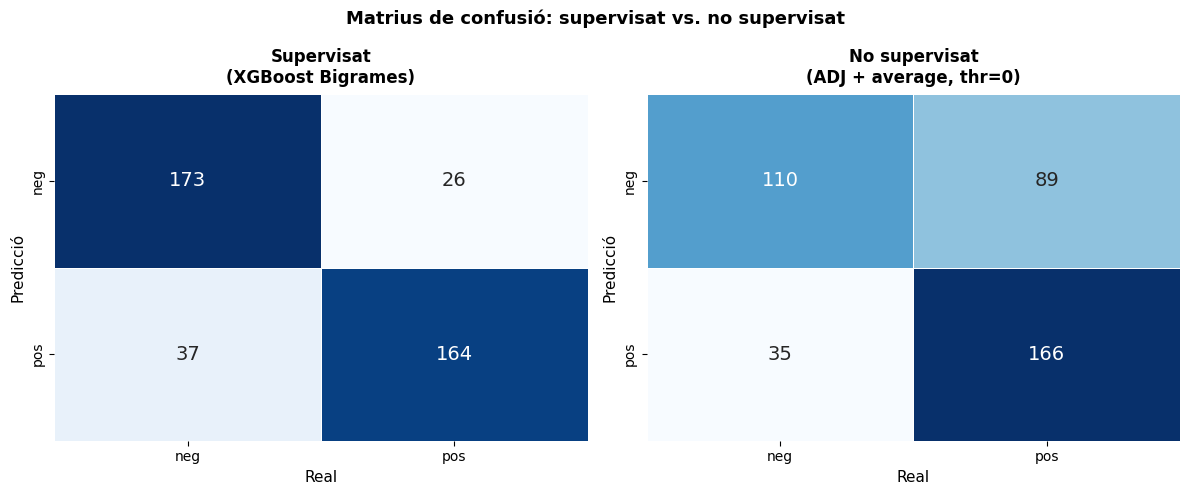

In [77]:
# GRÀFIC 2: MATRIUS DE CONFUSIÓ

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
    axes,
    [cm_sup, cm_ns],
    ["Supervisat\n(XGBoost Bigrames)", "No supervisat\n(ADJ + average, thr=0)"]
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["neg", "pos"],
        yticklabels=["neg", "pos"],
        ax=ax,
        cbar=False,
        linewidths=0.5,
        annot_kws={"size": 14}
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Real",      fontsize=11)
    ax.set_ylabel("Predicció", fontsize=11)

fig.suptitle("Matrius de confusió: supervisat vs. no supervisat",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("matrius_sup_vs_ns.png", dpi=150, bbox_inches="tight")
plt.show()

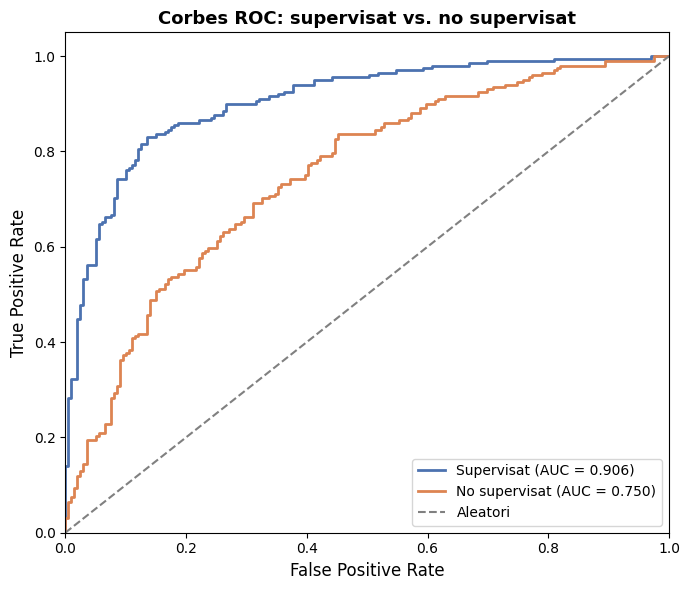

In [79]:
# GRÀFIC 3: CORBES ROC 

# Corba ROC no supervisat (ja calculada)
fpr_ns  = unsupervised_results["ADJ"]["average"]["fpr"]
tpr_ns  = unsupervised_results["ADJ"]["average"]["tpr"]

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_sup, tpr_sup, color="#4C72B0", lw=2,
        label=f"Supervisat (AUC = {auc_sup:.3f})")
ax.plot(fpr_ns,  tpr_ns,  color="#DD8452", lw=2,
        label=f"No supervisat (AUC = {auc_ns:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1.5, label="Aleatori")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title("Corbes ROC: supervisat vs. no supervisat", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("roc_sup_vs_ns.png", dpi=150, bbox_inches="tight")
plt.show()


Els resultats de la comparació mostren una diferència clara i consistent entre els dos enfocaments. El model supervisat (XGBoost amb bigrames) supera el model no supervisat (ADJ + average, llindar 0) en gairebé totes les mètriques: l'accuracy passa del 69.0% al 84.25%, el F1-Score del 0.728 al 0.839, i l'AUC del 0.750 al 0.906. L'única mètrica on el model no supervisat s'aproxima al supervisat és el recall (0.826 vs. 0.816), cosa que reflecteix el biaix positiu estructural del model lèxic: detecta bé les ressenyes positives però a costa de classificar moltes negatives incorrectament.

En termes absoluts, el model supervisat comet 63 errors sobre 400 mostres (15.75%), mentre que el no supervisat en comet 124 (31.00%), el doble exactament. Aquesta diferència de 61 errors quantifica de manera concreta el cost d'eliminar la supervisió en aquesta tasca.

Les matrius de confusió permeten aprofundir en la naturalesa d'aquesta diferència. El model supervisat distribueix els errors de manera força equilibrada: 26 falsos positius i 37 falsos negatius, amb una lleu tendència a predire negatiu. El model no supervisat, en canvi, presenta un desequilibri molt pronunciat: només 35 falsos positius però 89 falsos negatius, cosa que indica que el lèxic de SentiWordNet aplicat als adjectius tendeix a generar puntuacions positives i, per tant, a classificar com a positives moltes ressenyes que no ho són. Paradoxalment, el model no supervisat detecta millor les ressenyes positives que el supervisat (166 vs. 164 veritables positius), però falla molt més en les negatives (110 vs. 173 veritables negatius).

### Conclusions finals

La comparació entre els dos sistemes confirma que l'aprenentatge supervisat ofereix un avantatge substancial sobre l'aproximació lèxica no supervisada en la tasca de detecció d'opinions sobre ressenyes cinematogràfiques. El model XGBoost amb bigrames supera en més de 15 punts percentuals d'accuracy i en més de 11 punts de F1-Score el millor model no supervisat, i redueix a la meitat el nombre d'errors absoluts.

No obstant això, és important contextualitzar aquest resultat. El model supervisat ha pogut aprendre patrons específics del domini cinematogràfic a partir de 1.600 ressenyes etiquetades, mentre que el model no supervisat no ha vist cap exemple i opera exclusivament amb coneixement lèxic genèric. Que el sistema no supervisat assoleixi un 69% d'accuracy en aquestes condicions és un resultat notable, i posa de manifest que recursos com SentiWordNet capturen una part significativa de la informació de sentiment present en el text.

Les limitacions de cada aproximació també són complementàries. El model supervisat, com s'ha vist en les seves conclusions individuals, pateix de biaix introduït per noms propis, ironia i ressenyes amb arc narratiu contradictori (problemes que no resol ni afegint bigrames). El model no supervisat comparteix aquests mateixos problemes però hi afegeix una incapacitat estructural per capturar el context global i les relacions entre paraules: tracta cada mot de manera independent i no pot detectar quan un vocabulari superficialment positiu s'usa en un registre crític o irònic.

En definitiva, la decisió entre un enfocament supervisat i un de no supervisat en una tasca real depèn fonamentalment de la disponibilitat de dades etiquetades. Quan les dades existeixen, el model supervisat és clarament superior. Quan no n'hi ha, el sistema lèxic no supervisat ofereix una línia de base raonable que, tot i les seves limitacions, supera significativament la classificació aleatòria i pot ser útil com a punt de partida o com a sistema de referència en tasques de detecció d'opinions.